

# **TECH CHALLENGE**

#**Análise do Projeto:**

**Predição de Aprovação de Pedidos de Cartão de Crédito Utilizando Aprendizado de Máquina**



## **1. Introdução**

O presente trabalho tem como finalidade desenvolver um modelo de aprendizado de máquina capaz de classificar clientes de acordo com seu perfil de pagamento, diferenciando clientes considerados **bons pagadores** daqueles classificados como **maus pagadores**.

Para isso, foram utilizadas duas bases de dados:

 - application_record.csv: contendo informações cadastrais e socioeconômicas dos clientes;

 - credit_record.csv: contendo o histórico mensal de pagamentos dos clientes.

O processo desenvolvido no notebook contempla as etapas de carregamento, tratamento e integração das bases, construção da variável-alvo, transformação das variáveis categóricas, análise exploratória por meio de estatísticas descritivas e correlações, separação entre treinamento e teste, balanceamento da variável-alvo, padronização dos dados e aplicação de quatro algoritmos de classificação.

Os modelos utilizados foram:

Random Forest;
K-Nearest Neighbors (KNN);
Support Vector Machine (SVM);
Regressão Logística.

Posteriormente, os modelos foram avaliados utilizando acurácia, matriz de confusão, precisão, recall, F1-score e curva ROC/AUC.

## **2. Objetivos**

O projeto estabeleceu os seguintes objetivos:

 - Realizar a limpeza e o pré-processamento da base de dados;

 - Analisar e explorar estatisticamente os atributos dos solicitantes;

 - Aplicar diferentes algoritmos de classificação e escolher aquele que melhor discrimina os perfis de bom e mau pagador;

 - Avaliar o desempenho dos modelos utilizando métricas apropriadas;

 - Interpretar os resultados e identificar as variáveis mais relevantes.

As etapas realizadas no notebook permitem atender a esses objetivos, conforme demonstrado a seguir.

## **3. Carregamento das bases de dados**

Inicialmente, foram importadas as bibliotecas necessárias para o desenvolvimento da análise.

Em seguida, foram carregadas as duas bases de dados:

- Base de clientes;
- Base de histórico de pagamentos.

A base de clientes contém informações como gênero, posse de carro e imóvel, número de filhos, renda, tipo de renda, escolaridade, estado civil, tipo de moradia, idade, tempo de emprego, telefone, e-mail e ocupação.

A base de pagamentos contém o identificador do cliente, o mês de observação e o status do pagamento.

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [123]:
df_clientes = pd.read_csv("application_record.csv")
df_pagamentos = pd.read_csv("credit_record.csv")

print("Clientes:", df_clientes.shape)
print("Pagamentos:", df_pagamentos.shape)

Clientes: (438557, 18)
Pagamentos: (1048575, 3)


In [124]:
display(df_clientes.head(3))
display(df_pagamentos.head(3))

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,"R$ 427,500.00",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,R$ 2.00
1,5008805,M,Y,Y,0,"R$ 427,500.00",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,R$ 2.00
2,5008806,M,Y,Y,0,"R$ 112,500.00",Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,R$ 2.00


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0


## **4. Padronização dos nomes das variáveis**

Uma das primeiras etapas realizadas foi a tradução e padronização dos nomes das colunas dos dois DataFrames.

Essa etapa facilita a interpretação das variáveis durante a análise e torna o notebook mais organizado, legível e acessível para futuros leitores e desenvolvedores.

In [125]:
clientes2 = {
    'ID': 'ID_Cliente',
    'CODE_GENDER': 'Genero',
    'FLAG_OWN_CAR': 'Possui_Carro',
    'FLAG_OWN_REALTY': 'Possui_Imovel',
    'CNT_CHILDREN': 'Num_Filhos',
    'AMT_INCOME_TOTAL': 'Renda_Total',
    'NAME_INCOME_TYPE': 'Tipo_Renda',
    'NAME_EDUCATION_TYPE': 'Grau_Escolaridade',
    'NAME_FAMILY_STATUS': 'Status_Familiar',
    'NAME_HOUSING_TYPE': 'Tipo_Moradia',
    'DAYS_BIRTH': 'Dias_Nascimento',
    'DAYS_EMPLOYED': 'Dias_Empregado',
    'FLAG_MOBIL': 'Possui_Celular',
    'FLAG_WORK_PHONE': 'Possui_Telefone_Trabalho',
    'FLAG_PHONE': 'Possui_Telefone',
    'FLAG_EMAIL': 'Possui_Email',
    'OCCUPATION_TYPE': 'Tipo_Ocupacao',
    'CNT_FAM_MEMBERS': 'Num_Membros_Familia',

}
df_clientes = df_clientes.rename(columns=clientes2)

In [126]:
pagamentos2 = {
    'ID': 'ID_Cliente',
    'MONTHS_BALANCE': 'Meses_Balanco',
    'STATUS': 'Status_Pagamento'}
df_pagamentos = df_pagamentos.rename(columns=pagamentos2)

## **5. Tratamento da base de dados de clientes**

Após o carregamento, foram realizadas verificações iniciais da estrutura da base.

A análise de valores ausentes mostrou que a principal variável com dados faltantes era:

* Tipo_Ocupacao: 134.203 valores ausentes.

Em vez de excluir esses registros, os valores ausentes foram substituídos pela categoria:

*"Desconhecido"*.

Essa decisão permitiu preservar os registros dos clientes, evitando uma redução desnecessária da base.

Depois do tratamento, a base continuou com:

438.557 registros e 18 variáveis.

Também foi realizada uma verificação de registros duplicados, não sendo encontrados registros duplicados nessa etapa.

In [127]:
df_clientes.head(3)

,ID_Cliente,Genero,Possui_Carro,Possui_Imovel,Num_Filhos,Renda_Total,Tipo_Renda,Grau_Escolaridade,Status_Familiar,Tipo_Moradia,Dias_Nascimento,Dias_Empregado,Possui_Celular,Possui_Telefone_Trabalho,Possui_Telefone,Possui_Email,Tipo_Ocupacao,Num_Membros_Familia
0,5008804,M,Y,Y,0,"R$ 427,500.00",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,R$ 2.00
1,5008805,M,Y,Y,0,"R$ 427,500.00",Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,R$ 2.00
2,5008806,M,Y,Y,0,"R$ 112,500.00",Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,R$ 2.00


In [128]:
df_clientes.shape

(438557, 18)

In [129]:
#Verificação de dados nulos/ausentes
df_clientes.isnull().sum()

,0
ID_Cliente,0
Genero,0
Possui_Carro,0
Possui_Imovel,0
Num_Filhos,0
Renda_Total,0
Tipo_Renda,0
Grau_Escolaridade,0
Status_Familiar,0
Tipo_Moradia,0


In [130]:
df_clientes['Tipo_Ocupacao'].value_counts(dropna=False)

,count
Tipo_Ocupacao,
NaN,134203
Laborers,78240
Core staff,43007
Sales staff,41098
Managers,35487
Drivers,26090
High skill tech staff,17289
Accountants,15985
Medicine staff,13520


In [131]:
#Substituição dos valores ausentes pela categoria "Desconhecido"
df_clientes_alterada = df_clientes.copy()
df_clientes_alterada['Tipo_Ocupacao'] = df_clientes_alterada['Tipo_Ocupacao'].fillna('Desconhecido')

In [132]:
df_clientes_alterada.isnull().sum()

,0
ID_Cliente,0
Genero,0
Possui_Carro,0
Possui_Imovel,0
Num_Filhos,0
Renda_Total,0
Tipo_Renda,0
Grau_Escolaridade,0
Status_Familiar,0
Tipo_Moradia,0


In [133]:
df_clientes_alterada.shape

(438557, 18)

In [134]:
df_clientes_alterada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID_Cliente                438557 non-null  int64  
 1   Genero                    438557 non-null  object 
 2   Possui_Carro              438557 non-null  object 
 3   Possui_Imovel             438557 non-null  object 
 4   Num_Filhos                438557 non-null  int64  
 5   Renda_Total               438557 non-null  float64
 6   Tipo_Renda                438557 non-null  object 
 7   Grau_Escolaridade         438557 non-null  object 
 8   Status_Familiar           438557 non-null  object 
 9   Tipo_Moradia              438557 non-null  object 
 10  Dias_Nascimento           438557 non-null  int64  
 11  Dias_Empregado            438557 non-null  int64  
 12  Possui_Celular            438557 non-null  int64  
 13  Possui_Telefone_Trabalho  438557 non-null  i

In [135]:
#Verificação de duplicatas
df_clientes_alterada.duplicated().sum()

np.int64(0)

## **6. Tratamento da base de dados de pagamentos**

Inicialmente, foram observados os seguintes status, com as respectivas quantidades de ocorrências:

 `C`: 442.031;

 `0`: 383.120;

 `X`: 209.230;

 `1`: 11.090;

 `5`: 1.693;

 `2`: 868;

 `3`: 320;

 `4`: 223.

Também foi verificado que não existiam valores ausentes nem registros duplicados nessa base.

In [136]:
df_pagamentos.head(3)

,ID_Cliente,Meses_Balanco,Status_Pagamento
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0


In [137]:
df_pagamentos.shape

(1048575, 3)

In [138]:
df_pagamentos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   ID_Cliente        1048575 non-null  int64 
 1   Meses_Balanco     1048575 non-null  int64 
 2   Status_Pagamento  1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [139]:
df_pagamentos["Status_Pagamento"].value_counts()

,count
Status_Pagamento,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


In [140]:
df_pagamentos['Status_Pagamento'].unique()

array(['X', '0', 'C', '1', '2', '3', '4', '5'], dtype=object)

In [141]:
#Verificação da existência de valores nulos/ausentes
df_pagamentos.isnull().sum()

,0
ID_Cliente,0
Meses_Balanco,0
Status_Pagamento,0


In [142]:
#Verificação de valores ausentes
df_pagamentos.duplicated().sum()

np.int64(0)

## **7. Interpretação dos status de pagamento**

Os códigos da variável Status_Pagamento foram interpretados conforme o dicionário da base:

- `0`: 1–29 dias em atraso
- `1`: 30–59 dias em atraso
- `2`: 60–89 dias em atraso
- `3`: 90–119 dias em atraso
- `4`: 120–149 dias em atraso
- `5`: 150+ dias em atraso / prejuízo
- `C`: quitado no mês
- `X`: sem empréstimo no mês


Para transformar essas informações em uma variável adequada para classificação, foi realizada uma categorização binária.

Foram considerados:

**Bons Pagadores** (Valor = 0): Clientes em dia ou com atraso inferior a **59 dias**

**Maus Pagadores** (Valor = 1): Clientes com atraso de **60 dias ou mais**

`X` não é contado como pagamento em dia. Clientes cujo histórico contém somente `X` não possuem exposição observável suficiente para criar um rótulo e são excluídos da modelagem supervisionada.

In [143]:
#Mapeando os clientes que receberam apenas o status X
pag = df_pagamentos.copy()
pag["tem_exposicao"] = pag["Status_Pagamento"].ne("X")

# Agrupando por cliente para ver quem tem pelo menos uma exposição diferente de X
exposicao_clientes = pag.groupby("ID_Cliente")["tem_exposicao"].sum()

# Clientes cuja soma de 'tem_exposicao' é 0 são aqueles que só possuem status X
somente_x = (exposicao_clientes == 0).sum()
print(f"Clientes do histórico com somente STATUS X: {somente_x:,}")

Clientes do histórico com somente STATUS X: 4,536


In [144]:
# Identificar os IDs dos clientes que só possuem status X
clientes_somente_x = exposicao_clientes[exposicao_clientes == 0].index

# Filtrar df_pagamentos para remover estes clientes
print(f"Formato original de df_pagamentos: {df_pagamentos.shape}")
df_pagamentos = df_pagamentos[~df_pagamentos["ID_Cliente"].isin(clientes_somente_x)]
print(f"Formato após remover clientes com apenas status X: {df_pagamentos.shape}")

Formato original de df_pagamentos: (1048575, 3)
Formato após remover clientes com apenas status X: (947052, 3)


In [145]:
df_pagamentos['Status'] = df_pagamentos['Status_Pagamento'].map({'C': 0, 'X': 0, '0': 0, '1': 0, '2': 1, '3': 1, '4': 1, '5': 1})

In [146]:
df_pagamentos["Status"].value_counts()

,count
Status,
0,943948
1,3104


In [147]:
df_pagamentos.head(3)

,ID_Cliente,Meses_Balanco,Status_Pagamento,Status
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0


In [148]:
df_pagamentos.shape

(947052, 4)

In [149]:
df_pagamentos['Status'].unique()

array([0, 1])

## **8. Criação dos indicadores de comportamento de pagamento**

Depois da transformação dos Status de pagamento, os registros foram agrupados por cliente.

Foram criadas três variáveis:

- **meses_observados** Representa a quantidade de meses disponíveis para cada cliente.

- **qtde_atrasos**     Representa a quantidade de ocorrências classificadas como inadimplência.

- **perc_atrasos**    Representa a proporção de meses em que o cliente apresentou atraso considerado relevante.

A fórmula utilizada para perc_atrasos equivale à média da variável binária de status.

Dessa forma, por exemplo, um cliente com 20 meses observados e 2 meses classificados como inadimplência terá aproximadamente:

perc_atrasos = 2 / 20 = 0,10

In [150]:
from re import X

df_pagamentos_analise = df_pagamentos.groupby('ID_Cliente').agg(

meses_observados=('Meses_Balanco', 'count'),
qtde_atrasos=('Status', 'sum'),
perc_atrasos=('Status', 'mean')
).reset_index()

In [151]:
df_pagamentos_analise.head(3)

,ID_Cliente,meses_observados,qtde_atrasos,perc_atrasos
0,5001711,4,0,R$ 0.00
1,5001712,19,0,R$ 0.00
2,5001717,22,0,R$ 0.00


In [152]:
df_pagamentos_analise['perc_atrasos'].value_counts()

,count
perc_atrasos,
R$ 0.00,40782
R$ 0.10,17
R$ 0.07,15
R$ 0.17,11
R$ 0.03,11
...,...
R$ 0.14,1
R$ 0.06,1
R$ 0.09,1


## **9. Integração das bases**

Após o tratamento dos dados, as bases foram integradas utilizando o identificador **ID_Cliente**.


Foi utilizado um inner join, garantindo que permanecessem apenas os clientes que estavam presentes tanto na base cadastral quanto na base de pagamentos.

Após a integração, foram encontrados:

- 33.110 clientes únicos.

A base integrada possuía inicialmente 21 variáveis antes da criação da variável-alvo.

In [153]:
df_clientes_alterada['ID_Cliente'].nunique()

438510

In [154]:
df_pagamentos_analise['ID_Cliente'].nunique()

41449

In [155]:
#Integração das bases de dados
df_clientes_pagamentos = pd.merge(
    df_clientes_alterada,
    df_pagamentos_analise,
    on="ID_Cliente", how='inner')

In [156]:
df_clientes_pagamentos['ID_Cliente'].nunique()

33110

In [157]:
#Exclusão de duplicatas
df_clientes_pagamentos = df_clientes_pagamentos.drop_duplicates(subset='ID_Cliente')

In [158]:
df_clientes_pagamentos.shape

(33110, 21)

In [159]:
#Verificação de existência de dados nulos após integração
df_clientes_pagamentos.isnull().sum()

,0
ID_Cliente,0
Genero,0
Possui_Carro,0
Possui_Imovel,0
Num_Filhos,0
Renda_Total,0
Tipo_Renda,0
Grau_Escolaridade,0
Status_Familiar,0
Tipo_Moradia,0


## **10. Construção da variável TARGET**

A variável-alvo binária do projeto foi chamada de: **target**

A regra utilizada foi:

* `1` quando `perc_atrasos > 0` (cliente que apresentou pelo menos um registro de inadimplência relevante)
* `0` quando `perc_atrasos = 0` (cliente sem registros de inadimplência relevante)

A distribuição encontrada foi:

| Classe | Classificação | Quantidade | Percentual Aproximado |
| :---: | :---: | :---: | :---: |
| **0** | Bom pagador | 32.494 | 98,14% |
| **1** | Mau pagador | 616 | 1,86% |
| **Total** | **Geral** | **33.110** | **100,00%** |

Esse resultado é muito importante para a análise porque demonstra que existe um forte desbalanceamento entre as classes.

A classe de **maus pagadores** representa somente aproximadamente **1,86% da base**.

Esse desbalanceamento justifica a utilização de técnicas de balanceamento no conjunto de treinamento durante a etapa de modelagem.

In [160]:
df_clientes_pagamentos['target'] = (df_clientes_pagamentos['perc_atrasos'] > 0).astype(int)

In [161]:
df_clientes_pagamentos['target'].value_counts()

,count
target,
0,32494
1,616


## **11. Preparação das váriaveis e análise exploratória e estatistíca**

Vamos estudar idade, renda, patrimônio, situação familiar e emprego.

Foi realizada a conversão da idade e do tempo de emprego que estavam originalmente em dias para anos, além da criação de faixas etárias, faixas de tempo de serviço e de renda para facilitar a análise.


In [162]:
# A coluna 'Dias_Nascimento' (originalmente DAYS_BIRTH) está em dias e é negativa. Dividimos por 365.25 para obter a idade em anos.
df_clientes_pagamentos['idade'] = np.floor(abs(df_clientes_pagamentos['Dias_Nascimento']) / 365.25)

In [163]:
# Substituímos a coluna Dias_Nascimento pela nova coluna 'idade'
df_clientes_pagamentos = df_clientes_pagamentos.drop(columns=['Dias_Nascimento'])

In [164]:
#Faixas etárias
bins_idade = [18, 25, 35, 45, 55, 65, np.inf]
labels_idade = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
df_clientes_pagamentos["faixa_idade"] = pd.cut(
    df_clientes_pagamentos["idade"],
    bins=bins_idade,
    labels=labels_idade,
    right=False
)


Verificamos que no dicionário de dados original, a variável DAYS_EMPLOYED (que traduzimos para Dias_Empregado) representa a contagem de dias trabalhados contados retroativamente a partir do dia atual:

**Valores Negativos:** Indicam há quantos dias o cliente iniciou seu emprego atual (por exemplo, -4542 significa que ele começou a trabalhar há 4.542 dias). Portanto, ele está atualmente **empregado**.

**Valores Positivos:** Se o valor for positivo, ele indica que o cliente está desempregado. Especificamente, a base utiliza o valor padrão constante 365243 (que equivale a exatamente 1000 anos) para registrar todos os clientes que **não possuem** um emprego ativo.
Por essa razão, qualquer valor maior que zero (especialmente o 365243) significa que o cliente é considerado **desempregado** no momento do cadastro.

In [165]:
#Tempo de serviço
# Desemprego - Valores positivos em 'Dias_Empregado' (como 365243) indicam desemprego
df_clientes_pagamentos["desempregado"] = (df_clientes_pagamentos["Dias_Empregado"] > 0).astype(int)

# Calcular o tempo de serviço em anos
# Se for empregado (Dias_Empregado negativo), convertemos para anos positivos; caso contrário, é 0
df_clientes_pagamentos["tempo_servico_anos"] = np.where(
    df_clientes_pagamentos["Dias_Empregado"] < 0,
    abs(df_clientes_pagamentos["Dias_Empregado"]) / 365.25,
    0
)

#Criação das faixas de tempo de serviço
bins_tempo_servico = [0, 1, 3, 5, 10, 20, np.inf]
labels_tempo_servico = [
    "Até 1 ano",
    "1 a 3 anos",
    "3 a 5 anos",
    "5 a 10 anos",
    "10 a 20 anos",
    "Acima de 20 anos"
]
df_clientes_pagamentos["faixa_tempo_servico"] = pd.cut(
    df_clientes_pagamentos["tempo_servico_anos"],
    bins=bins_tempo_servico,
    labels=labels_tempo_servico,
    right=False
)

In [166]:
#Faixas de renda por quantis

df_clientes_pagamentos["faixa_renda"] = pd.qcut(
    df_clientes_pagamentos["Renda_Total"], q=5,
    labels=["Muito baixa",
            "Baixa",
            "Média",
            "Alta",
            "Muito alta"],
    duplicates="drop"
)


###11.1 Análise da Distribuição Demográfica

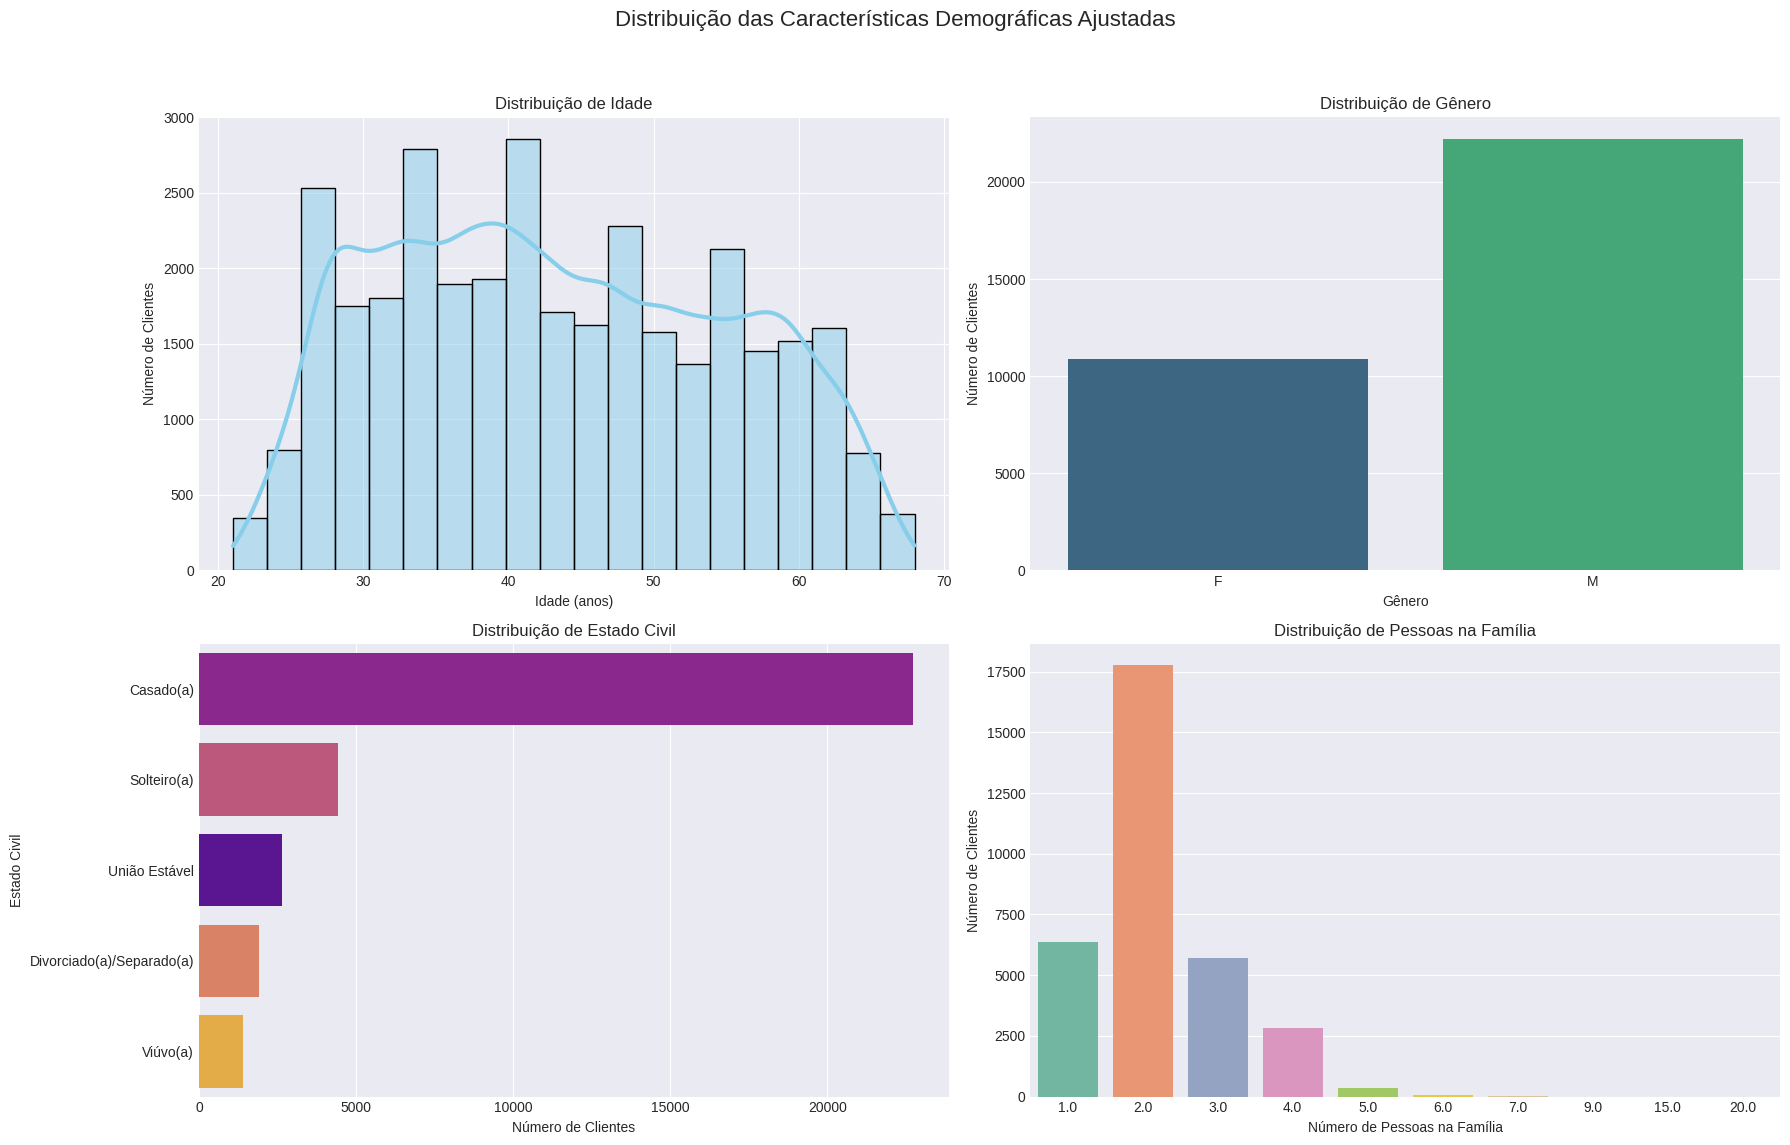

In [167]:
# Dicionário de tradução para exibição gráfica
mapeamento_civil = {
    'Married': 'Casado(a)',
    'Single / not married': 'Solteiro(a)',
    'Civil marriage': 'União Estável',
    'Separated': 'Divorciado(a)/Separado(a)',
    'Widow': 'Viúvo(a)'
}

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
fig.suptitle('Distribuição das Características Demográficas Ajustadas', fontsize=16)

# Distribuição de Idade com Linha de Densidade Destacada
sns.histplot(
    df_clientes_pagamentos['idade'],
    bins=20,
    kde=True,
    ax=axes[0, 0],
    color='skyblue',
    line_kws={'color': 'darkorange', 'linewidth': 3}
)
axes[0, 0].set_title('Distribuição de Idade')
axes[0, 0].set_xlabel('Idade (anos)')
axes[0, 0].set_ylabel('Número de Clientes')

# Distribuição de Gênero
genero_plot = sns.countplot(
    x='Genero',
    data=df_clientes_pagamentos,
    ax=axes[0, 1],
    palette='viridis',
    hue='Genero',
    legend=False
)
axes[0, 1].set_title('Distribuição de Gênero')
axes[0, 1].set_xlabel('Gênero')
axes[0, 1].set_ylabel('Número de Clientes')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['F', 'M'])

# Distribuição de Estado Civil (Tradução direta na exibição gráfica sem criar nova coluna)
ordem_civil = df_clientes_pagamentos['Status_Familiar'].value_counts().index
estado_civil_plot = sns.countplot(
    y='Status_Familiar',
    data=df_clientes_pagamentos,
    ax=axes[1, 0],
    palette='plasma',
    order=ordem_civil,
    hue='Status_Familiar',
    legend=False
)
axes[1, 0].set_title('Distribuição de Estado Civil')
axes[1, 0].set_xlabel('Número de Clientes')
axes[1, 0].set_ylabel('Estado Civil')

# Define explicitamente a localização dos ticks e mapeia as categorias do eixo Y para português sem gerar avisos
axes[1, 0].set_yticks(range(len(ordem_civil)))
labels_traduzidos = [mapeamento_civil.get(label.get_text(), label.get_text()) for label in axes[1, 0].get_yticklabels()]
axes[1, 0].set_yticklabels(labels_traduzidos)

# Distribuição por Pessoas na Família
familia_plot = sns.countplot(
    x='Num_Membros_Familia',
    data=df_clientes_pagamentos,
    ax=axes[1, 1],
    palette='Set2',
    hue='Num_Membros_Familia',
    legend=False
)
axes[1, 1].set_title('Distribuição de Pessoas na Família')
axes[1, 1].set_xlabel('Número de Pessoas na Família')
axes[1, 1].set_ylabel('Número de Clientes')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 11.2 Análise de Propensão ao Atraso por Grupo Demográfico

In [168]:
def analisar_grupo(df, grupo_coluna):
    analise = df.groupby(grupo_coluna, observed=True).agg(
        media_risco_inadimplencia=('target', lambda x: x.mean() * 100),
        media_renda_anual=('Renda_Total', 'mean'),
        mediana_renda_anual=('Renda_Total', 'median'),
        num_clientes=('ID_Cliente', 'count')
    ).reset_index()

    analise['media_risco_inadimplencia'] = analise['media_risco_inadimplencia'].round(2)
    analise['media_renda_anual'] = analise['media_renda_anual'].round(2)
    analise['mediana_renda_anual'] = analise['mediana_renda_anual'].round(2)
    return analise.sort_values(by='media_risco_inadimplencia', ascending=False)

print("\nAnálise por Faixa Etária:")
analise_idade = analisar_grupo(df_clientes_pagamentos, 'faixa_idade')
print(analise_idade.to_string())

print("\nAnálise por Gênero:")
analise_genero = analisar_grupo(df_clientes_pagamentos, 'Genero')
print(analise_genero.to_string())

print("\nAnálise por Estado Civil:")
analise_estado_civil = analisar_grupo(df_clientes_pagamentos, 'Status_Familiar')
print(analise_estado_civil.to_string())

print("\nAnálise por Quantidade de Pessoas na Família:")
analise_qtd_pessoas_familia = analisar_grupo(df_clientes_pagamentos, 'Num_Membros_Familia')
print(analise_qtd_pessoas_familia.to_string())



Análise por Faixa Etária:
  faixa_idade  media_risco_inadimplencia  media_renda_anual  mediana_renda_anual  num_clientes
5         65+                    R$ 2.63      R$ 132,365.46        R$ 126,000.00           684
1       25-34                    R$ 2.13      R$ 185,900.89        R$ 157,500.00          8406
3       45-54                    R$ 2.00      R$ 195,881.03        R$ 180,000.00          7637
4       55-64                    R$ 1.66      R$ 166,005.68        R$ 139,500.00          6383
2       35-44                    R$ 1.60      R$ 196,255.81        R$ 180,000.00          9296
0       18-24                    R$ 1.56      R$ 172,188.29        R$ 157,500.00           704

Análise por Gênero:
  Genero  media_risco_inadimplencia  media_renda_anual  mediana_renda_anual  num_clientes
1      M                    R$ 2.18      R$ 214,617.80        R$ 198,000.00         10890
0      F                    R$ 1.71      R$ 171,791.42        R$ 157,500.00         22220

Análise por Esta

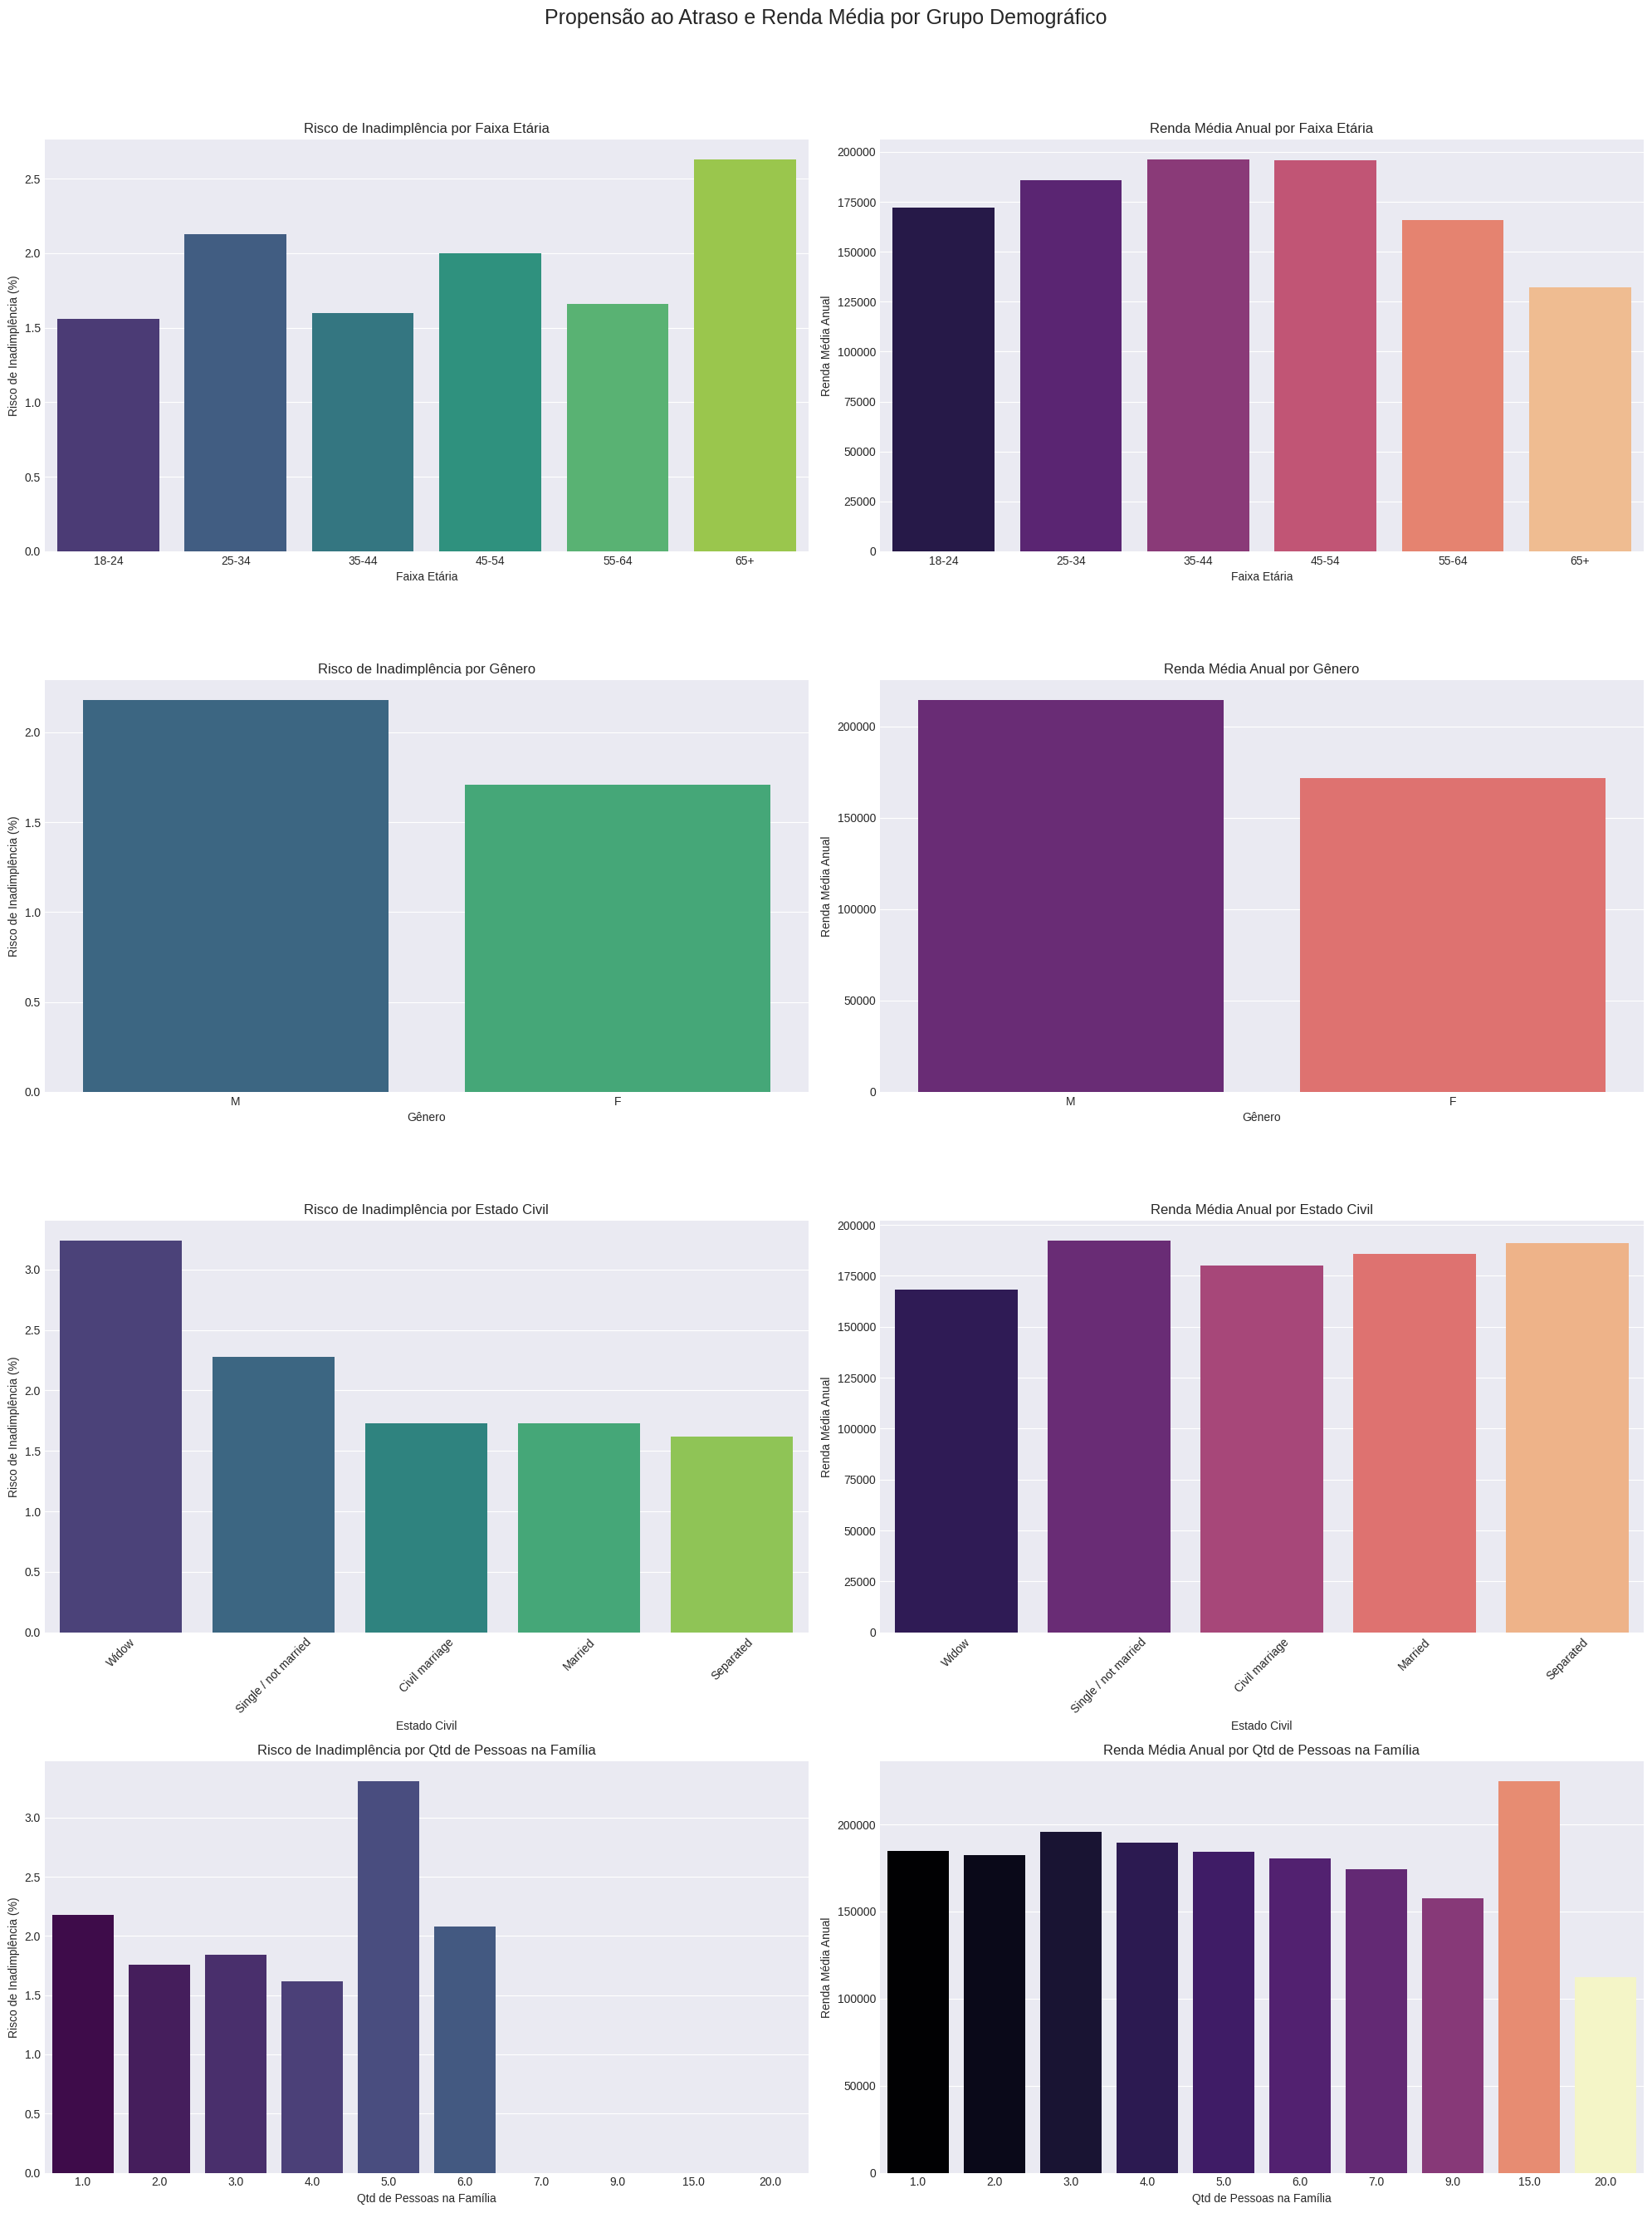

In [169]:
#Visualizações para a relação entre demografia, risco de inadimplência e renda

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 28))
fig.suptitle('Propensão ao Atraso e Renda Média por Grupo Demográfico', fontsize=18)

# --- Faixa Etária ---
sns.barplot(x='faixa_idade', y='media_risco_inadimplencia', data=analise_idade, ax=axes[0, 0], palette='viridis', hue='faixa_idade', legend=False)
axes[0, 0].set_title('Risco de Inadimplência por Faixa Etária')
axes[0, 0].set_xlabel('Faixa Etária')
axes[0, 0].set_ylabel('Risco de Inadimplência (%)')

sns.barplot(x='faixa_idade', y='media_renda_anual', data=analise_idade, ax=axes[0, 1], palette='magma', hue='faixa_idade', legend=False)
axes[0, 1].set_title('Renda Média Anual por Faixa Etária')
axes[0, 1].set_xlabel('Faixa Etária')
axes[0, 1].set_ylabel('Renda Média Anual')

# --- Gênero ---
sns.barplot(x='Genero', y='media_risco_inadimplencia', data=analise_genero, ax=axes[1, 0], palette='viridis', hue='Genero', legend=False)
axes[1, 0].set_title('Risco de Inadimplência por Gênero')
axes[1, 0].set_xlabel('Gênero')
axes[1, 0].set_ylabel('Risco de Inadimplência (%)')

sns.barplot(x='Genero', y='media_renda_anual', data=analise_genero, ax=axes[1, 1], palette='magma', hue='Genero', legend=False)
axes[1, 1].set_title('Renda Média Anual por Gênero')
axes[1, 1].set_xlabel('Gênero')
axes[1, 1].set_ylabel('Renda Média Anual')

# --- Estado Civil ---
sns.barplot(x='Status_Familiar', y='media_risco_inadimplencia', data=analise_estado_civil, ax=axes[2, 0], palette='viridis', hue='Status_Familiar', legend=False)
axes[2, 0].set_title('Risco de Inadimplência por Estado Civil')
axes[2, 0].set_xlabel('Estado Civil')
axes[2, 0].set_ylabel('Risco de Inadimplência (%)')
axes[2, 0].tick_params(axis='x', rotation=45)

sns.barplot(x='Status_Familiar', y='media_renda_anual', data=analise_estado_civil, ax=axes[2, 1], palette='magma', hue='Status_Familiar', legend=False)
axes[2, 1].set_title('Renda Média Anual por Estado Civil')
axes[2, 1].set_xlabel('Estado Civil')
axes[2, 1].set_ylabel('Renda Média Anual')
axes[2, 1].tick_params(axis='x', rotation=45)

# --- Quantidade de Pessoas na Família ---
sns.barplot(x='Num_Membros_Familia', y='media_risco_inadimplencia', data=analise_qtd_pessoas_familia, ax=axes[3, 0], palette='viridis', hue='Num_Membros_Familia', legend=False)
axes[3, 0].set_title('Risco de Inadimplência por Qtd de Pessoas na Família')
axes[3, 0].set_xlabel('Qtd de Pessoas na Família')
axes[3, 0].set_ylabel('Risco de Inadimplência (%)')

sns.barplot(x='Num_Membros_Familia', y='media_renda_anual', data=analise_qtd_pessoas_familia, ax=axes[3, 1], palette='magma', hue='Num_Membros_Familia', legend=False)
axes[3, 1].set_title('Renda Média Anual por Qtd de Pessoas na Família')
axes[3, 1].set_xlabel('Qtd de Pessoas na Família')
axes[3, 1].set_ylabel('Renda Média Anual')


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


**Resultados da Análise:**

**Faixa Etária:** Os grupos mais jovens ('18-24' e '25-34') apresentam uma propensão ao atraso ligeiramente maior, enquanto o grupo '55-64' tem a menor. A renda média tende a ser maior em faixas etárias intermediárias ('35-44').

**Gênero:** Homens ('M') mostram uma propensão ao atraso um pouco maior e uma renda anual média significativamente mais alta do que as mulheres ('F').

**Estado Civil:** 'Single / not married' (Solteiro/não casado) apresenta a maior propensão ao atraso, e 'Widow' (Viúvo/a) a menor.

**Quantidade de Pessoas na Família:** Grupos com poucas pessoas na família (1, 2, 3) geralmente têm menor propensão ao atraso. Grupos com muitas pessoas na família (e.g., 15, 9), embora com poucos clientes, mostram uma alta propensão.

### 11.3 Análise da Distribuição da Renda Anual

In [170]:
estat_renda = df_clientes_pagamentos["Renda_Total"].describe()
display(estat_renda)

# Iremos calcular o 99º percentil da renda anual para definir um limite superior para os gráficos

income_threshold = df_clientes_pagamentos["Renda_Total"].quantile(0.99)
print(f"Média: R$ {estat_renda['mean']:,.2f}")
print(f"Mediana: R$ {estat_renda['50%']:,.2f}")
print(f"Desvio padrão: R$ {estat_renda['std']:,.2f}")
print(f"Mínimo: R$ {estat_renda['min']:,.2f}")
print(f"Máximo: R$ {estat_renda['max']:,.2f}")
print(f"99º percentil: R$ {income_threshold:,.2f}")

,Renda_Total
count,"R$ 33,110.00"
mean,"R$ 185,877.17"
std,"R$ 101,412.41"
min,"R$ 27,000.00"
25%,"R$ 121,500.00"
50%,"R$ 157,500.00"
75%,"R$ 225,000.00"
max,"R$ 1,575,000.00"


Média: R$ 185,877.17
Mediana: R$ 157,500.00
Desvio padrão: R$ 101,412.41
Mínimo: R$ 27,000.00
Máximo: R$ 1,575,000.00
99º percentil: R$ 560,250.00


**Distribuição Geral da Renda Anual:**
* **Disparidade de Renda:** A renda média dos clientes cadastrados é de aproximadamente **R\$ 185.877,17**, enquanto a mediana se situa em **R\$ 157.500,00**. A diferença entre a média e a mediana, somada ao alto desvio padrão (**R\$ 101.412,41**), indica uma distribuição de renda consideravelmente distorcida à direita, com a presença de *outliers* de altíssima renda (máximo de **R$ 1.575.000,00**).

* **Limite Prático (99º Percentil):** 99% da base de clientes possui renda anual de até **R$ 560.250,00**. Focar a análise gráfica abaixo deste limite permite visualizar melhor o comportamento da esmagadora maioria dos clientes cadastrados.

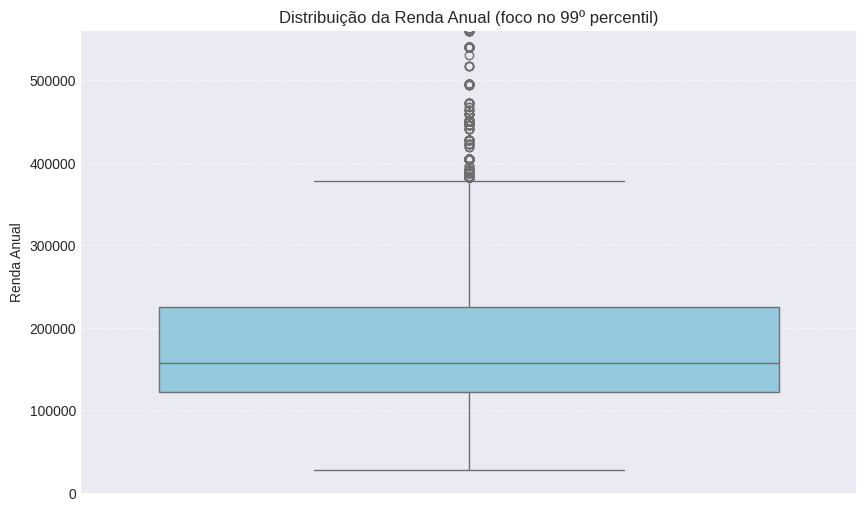

In [171]:
#Distribuição da Renda Total Anual
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_clientes_pagamentos['Renda_Total'], color='skyblue')
plt.title('Distribuição da Renda Anual (foco no 99º percentil)')
plt.ylabel('Renda Anual')
plt.ylim(0, income_threshold)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

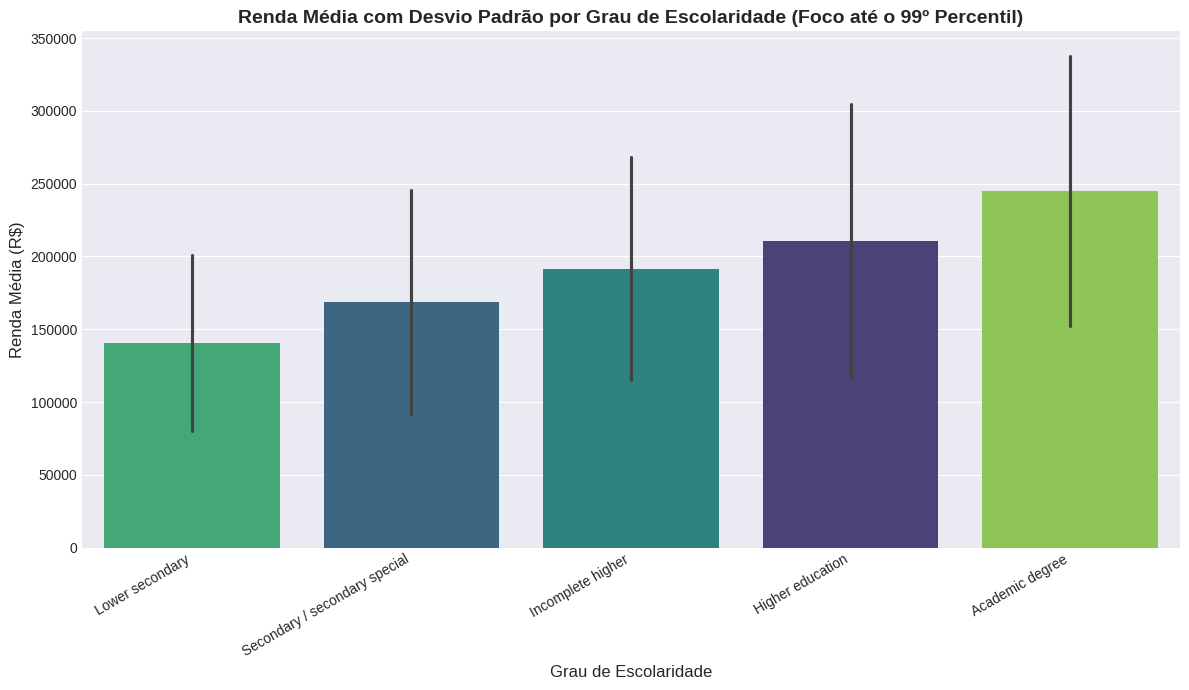

In [172]:
#Distribuição da Renda Média por Escolaridade
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 7))

ordem_escolaridade_media = df_clientes_pagamentos.groupby('Grau_Escolaridade')['Renda_Total'].mean().sort_values().index

sns.barplot(
    x='Grau_Escolaridade',
    y='Renda_Total',
    data=df_clientes_pagamentos[df_clientes_pagamentos['Renda_Total'] <= income_threshold],
    order=ordem_escolaridade_media,
    palette='viridis',
    hue='Grau_Escolaridade',
    errorbar='sd', # Exibe o desvio padrão como barra de erro
    legend=False
)

plt.title('Renda Média com Desvio Padrão por Grau de Escolaridade (Foco até o 99º Percentil)', fontsize=14, fontweight='bold')
plt.xlabel('Grau de Escolaridade', fontsize=12)
plt.ylabel('Renda Média (R$)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.show()

 Resumo da Análise de Renda e Escolaridade

**Renda Média por Grau de Escolaridade:**
* **Relação Direta:** Existe uma clara e consistente correlação positiva entre o nível formal de educação e a renda média anual declarada pelos clientes.
* **Destaques por Categoria:**
  * **Academic degree (Título acadêmico):** Apresenta a maior renda média disparada do conjunto de dados, porém com um desvio padrão bastante acentuado, indicando alta variabilidade interna dentro deste grupo altamente qualificado.
  * **Higher education (Ensino superior):** Garante a segunda maior média salarial, mantendo uma posição confortável de destaque financeiro frente aos demais grupos.
  * **Secondary / Incomplete higher (Ensino médio e Superior incompleto):** Apresentam rendas médias intermediárias e muito semelhantes entre si.
  * **Lower secondary (Ensino fundamental):** Registra a menor renda média anual declarada entre todas as categorias analisadas.

Os resultados indicam uma associação entre o nível de escolaridade e a renda média declarada pelos clientes. De modo geral, categorias com maior nível de escolaridade apresentaram maiores rendas médias, embora exista variabilidade dentro de cada grupo.


### 11.4 Análise do Impacto de Patrimônio (Carro e Imóvel), Tempo de emprego e Dados de contato

In [173]:
def resumo_grupo(coluna):
    return (
        df_clientes_pagamentos.groupby(coluna)
        .agg(
            taxa_inadimplencia=("target", "mean"),
            renda_media=("Renda_Total", "mean"),
            clientes=("ID_Cliente", "count")
        )
        .assign(taxa_inadimplencia=lambda d: (d["taxa_inadimplencia"] * 100).round(2))
        .round(2)
    )

print("Posse de carro:")
display(resumo_grupo("Possui_Carro"))

print("Posse de imóvel:")
display(resumo_grupo("Possui_Imovel"))

print("Situação de emprego:")
display(resumo_grupo("desempregado"))

print("Telefone corporativo:")
display(resumo_grupo("Possui_Telefone"))

print("E-mail:")
display(resumo_grupo("Possui_Email"))

Posse de carro:


,taxa_inadimplencia,renda_media,clientes
Possui_Carro,,,
N,R$ 1.90,"R$ 168,774.15",20618
Y,R$ 1.79,"R$ 214,105.64",12492


Posse de imóvel:


,taxa_inadimplencia,renda_media,clientes
Possui_Imovel,,,
N,R$ 2.32,"R$ 181,217.42",10822
Y,R$ 1.64,"R$ 188,139.72",22288


Situação de emprego:


,taxa_inadimplencia,renda_media,clientes
desempregado,,,
0,R$ 1.83,"R$ 193,504.53",27468
1,R$ 2.00,"R$ 148,743.46",5642


Telefone corporativo:


,taxa_inadimplencia,renda_media,clientes
Possui_Telefone,,,
0,R$ 1.84,"R$ 184,676.11",23428
1,R$ 1.91,"R$ 188,783.43",9682


E-mail:


,taxa_inadimplencia,renda_media,clientes
Possui_Email,,,
0,R$ 1.87,"R$ 182,906.71",30117
1,R$ 1.74,"R$ 215,767.35",2993


Resumo da Análise de Patrimônio, Emprego e dados de contato

**Posse de Carro:**
- Geralmente, clientes que **possuem carro** tendem a ter uma **renda anual média maior** e uma **propensão ao atraso ligeiramente menor** em comparação com aqueles que não possuem. Isso pode indicar uma maior estabilidade financeira entre os proprietários de veículos.

**Posse de Imóvel:**
- A posse de **imóvel** também está associada a uma **renda anual média mais alta** e, de forma consistente, a uma **menor propensão ao atraso**. A propriedade imobiliária é frequentemente um sinal de estabilidade econômica e compromisso financeiro, o que se reflete em um menor risco de inadimplência.

**Emprego:**
- O status de **emprego** é um indicador crucial de estabilidade profissional.
  - Clientes **nunca empregados** ou com **muito pouco tempo de serviço** tendem a apresentar a **maior propensão ao atraso** e a **menor renda anual média**.
  - Observa-se uma tendência de **diminuição da propensão ao atraso** e **aumento da renda média** conforme o **tempo de serviço aumenta**. Clientes com 10-20 anos ou mais de serviço geralmente demonstram maior estabilidade e menor risco.
  - A categoria de 'Desempregados' mostra uma propensão ao atraso significativamente maior, o que é esperado devido à falta de histórico de renda regular.

Em suma, **maior patrimônio (carro e imóvel) e maior tempo de serviço** são fatores que indicam **maior estabilidade financeira** e estão correlacionados com **maior renda anual** e **menor risco de atraso nos pagamentos**.

### 11.5 Tipo de residência por Faixa Etária

Proporção de Tipos de Residência por Faixa Etária:


Tipo_Moradia,Co-op apartment,House / apartment,Municipal apartment,Office apartment,Rented apartment,With parents
faixa_idade,,,,,,
18-24,R$ 0.01,R$ 0.65,R$ 0.04,R$ 0.00,R$ 0.05,R$ 0.24
25-34,R$ 0.00,R$ 0.83,R$ 0.03,R$ 0.01,R$ 0.02,R$ 0.11
35-44,R$ 0.01,R$ 0.89,R$ 0.03,R$ 0.01,R$ 0.02,R$ 0.04
45-54,R$ 0.00,R$ 0.92,R$ 0.04,R$ 0.01,R$ 0.01,R$ 0.01
55-64,R$ 0.00,R$ 0.96,R$ 0.03,R$ 0.00,R$ 0.00,R$ 0.00
65+,R$ 0.00,R$ 0.98,R$ 0.02,R$ 0.00,R$ 0.00,R$ 0.00


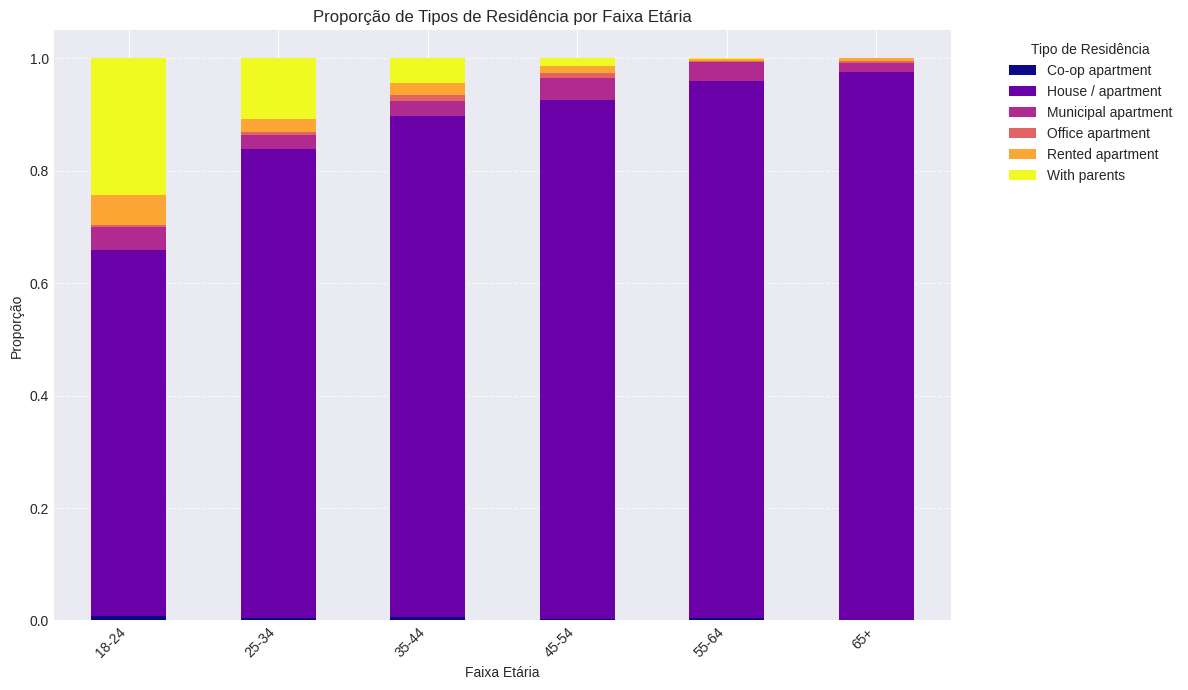

In [174]:
# Agrupar por faixa etária e tipo de residência para contar clientes
residencia_idade = df_clientes_pagamentos.groupby(['faixa_idade', 'Tipo_Moradia'], observed=True).size().unstack(fill_value=0)

# Calcular a proporção de cada tipo de residência dentro de cada faixa etária
residencia_idade_proporcao = residencia_idade.apply(lambda x: x / x.sum(), axis=1)

print("Proporção de Tipos de Residência por Faixa Etária:")
display(residencia_idade_proporcao.round(2))

residencia_idade_proporcao.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='plasma')
plt.title('Proporção de Tipos de Residência por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Proporção')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo de Residência', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Predominância de Propriedade:** Em todas as faixas etárias, a maioria dos clientes reside em 'House / apartment' (casa/apartamento próprio), o que sugere um perfil de clientes com certa estabilidade financeira. Essa proporção atinge seu pico nas faixas etárias intermediárias (35-54 anos).

**Jovens e Moradia:** Os grupos mais jovens (18-24 e 25-34 anos) apresentam uma proporção visivelmente maior de clientes morando 'With parents' (com os pais) ou em 'Rented apartment' (apartamento alugado), o que é esperado para o início da vida adulta e formação profissional, antes da aquisição de um imóvel próprio.

**Estabilidade com a Idade:** Conforme a idade avança, a proporção de 'House / apartment' se mantém alta e a de 'With parents' diminui drasticamente, indicando uma maior independência e estabilidade habitacional ao longo da vida adulta. As faixas etárias mais maduras (acima de 45 anos) mostram uma consolidação da posse de imóvel.

**Outros Tipos:** Tipos de residência como 'Co-op apartment', 'Municipal apartment' e 'Office apartment' representam uma parcela muito pequena em todas as faixas etárias

## **12. Conversão das variáveis categóricas**

Para que os algoritmos de aprendizado de máquina possam utilizar as informações categóricas, foi necessário convertê-las para representação numérica.

Foram utilizadas duas estratégias:

 - **Label Encoding**

 - **Dummies**

Dessa maneira, cada categoria passou a ser representada por uma variável binária.

Posteriormente, as variáveis categóricas originais foram removidas para evitar duplicidade de informação.

Removemos `Possui_Celular`  por apresentar o mesmo valor para todos os clientes. Também retiramos `qtde_atrasos` e `perc_atrasos` utilizadas para construção da target

In [175]:
from sklearn.preprocessing import LabelEncoder


In [176]:
set(df_clientes_pagamentos["Genero"])

{'F', 'M'}

In [177]:
set(df_clientes_pagamentos['Possui_Imovel'])

{'N', 'Y'}

In [178]:
set(df_clientes_pagamentos['Possui_Carro'])

{'N', 'Y'}

In [179]:
#Conversão das variáveis categóricas com apenas duas categorias (Genero, Possui_Imovel e Possui_Carro) em variáveis binárias
Colunas = ['Genero', 'Possui_Imovel', 'Possui_Carro']
LabelEncoder_X = LabelEncoder()
for col in Colunas:
    df_clientes_pagamentos[col] = LabelEncoder_X.fit_transform(df_clientes_pagamentos[col])

In [180]:
# Criando dummies para as faixas de renda, escolaridade, status familiar e tipo de moradia e adicionando ao conjunto de dados transformados
dummy_faixa_renda = pd.get_dummies(df_clientes_pagamentos['faixa_renda'], prefix='dummyFaixaRenda')
dummy_faixa_idade = pd.get_dummies(df_clientes_pagamentos['faixa_idade'], prefix='dummyFaixaIdade')
dummy_Grau_Escolaridade = pd.get_dummies(df_clientes_pagamentos['Grau_Escolaridade'], prefix='dummyEscolaridade')
dummy_Status_Familiar = pd.get_dummies(df_clientes_pagamentos['Status_Familiar'], prefix='dummyFamiliar')
dummy_Tipo_Moradia = pd.get_dummies(df_clientes_pagamentos['Tipo_Moradia'], prefix='dummyMoradia')

In [181]:
# Concatenando ao DataFrame de dummies existente
df_clientes_pagamentos_dummy = pd.concat([df_clientes_pagamentos, dummy_faixa_renda, dummy_faixa_idade, dummy_Grau_Escolaridade, dummy_Status_Familiar, dummy_Tipo_Moradia], axis=1)

In [182]:
# Convertendo os booleanos das novas dummies para 0 ou 1
bool_cols = df_clientes_pagamentos_dummy.select_dtypes(include='bool').columns
df_clientes_pagamentos_dummy[bool_cols] = (df_clientes_pagamentos_dummy[bool_cols].astype(int))

In [183]:
# Atualizando o 'df'
df = df_clientes_pagamentos_dummy

In [184]:
##Remoção das colunas categóricas originais para evitar duplicidade de informação:
df= df.drop(columns=['faixa_renda', 'faixa_idade', 'faixa_tempo_servico', 'Tipo_Renda', 'Grau_Escolaridade', 'Status_Familiar', 'Tipo_Moradia','Tipo_Ocupacao'])


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33110 entries, 0 to 33109
Data columns (total 46 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   ID_Cliente                                       33110 non-null  int64  
 1   Genero                                           33110 non-null  int64  
 2   Possui_Carro                                     33110 non-null  int64  
 3   Possui_Imovel                                    33110 non-null  int64  
 4   Num_Filhos                                       33110 non-null  int64  
 5   Renda_Total                                      33110 non-null  float64
 6   Dias_Empregado                                   33110 non-null  int64  
 7   Possui_Celular                                   33110 non-null  int64  
 8   Possui_Telefone_Trabalho                         33110 non-null  int64  
 9   Possui_Telefone             

In [186]:
df['Possui_Celular'].unique()

array([1])

In [187]:
#Remoção da variável Possui_Celular
df = df.drop(columns=['Possui_Celular'])

## **13. Análise de correlação**

Foi realizada uma análise de correlação entre as variáveis numéricas e a variável target.

Também foi construído um mapa de calor para facilitar a visualização das relações entre as variáveis.


In [188]:
corr = df.corr()

corr


,ID_Cliente,Genero,Possui_Carro,Possui_Imovel,Num_Filhos,Renda_Total,Dias_Empregado,Possui_Telefone_Trabalho,Possui_Telefone,Possui_Email,...,dummyFamiliar_Married,dummyFamiliar_Separated,dummyFamiliar_Single / not married,dummyFamiliar_Widow,dummyMoradia_Co-op apartment,dummyMoradia_House / apartment,dummyMoradia_Municipal apartment,dummyMoradia_Office apartment,dummyMoradia_Rented apartment,dummyMoradia_With parents
ID_Cliente,R$ 1.00,R$ 0.01,R$ -0.01,R$ -0.10,R$ 0.03,R$ -0.01,R$ -0.04,R$ 0.08,R$ 0.01,R$ -0.05,...,R$ 0.01,R$ -0.01,R$ 0.02,R$ -0.03,R$ 0.02,R$ -0.02,R$ 0.01,R$ 0.02,R$ -0.01,R$ 0.03
Genero,R$ 0.01,R$ 1.00,R$ 0.36,R$ -0.05,R$ 0.08,R$ 0.20,R$ -0.17,R$ 0.06,R$ -0.03,R$ 0.00,...,R$ 0.11,R$ -0.06,R$ -0.01,R$ -0.14,R$ 0.02,R$ -0.06,R$ -0.02,R$ 0.04,R$ 0.05,R$ 0.06
Possui_Carro,R$ -0.01,R$ 0.36,R$ 1.00,R$ -0.02,R$ 0.11,R$ 0.22,R$ -0.15,R$ 0.02,R$ -0.01,R$ 0.02,...,R$ 0.15,R$ -0.06,R$ -0.08,R$ -0.09,R$ 0.02,R$ -0.01,R$ -0.03,R$ 0.02,R$ 0.00,R$ 0.02
Possui_Imovel,R$ -0.10,R$ -0.05,R$ -0.02,R$ 1.00,R$ -0.01,R$ 0.03,R$ 0.09,R$ -0.20,R$ -0.06,R$ 0.05,...,R$ 0.01,R$ -0.01,R$ -0.00,R$ 0.03,R$ -0.01,R$ 0.20,R$ -0.12,R$ -0.04,R$ -0.02,R$ -0.15
Num_Filhos,R$ 0.03,R$ 0.08,R$ 0.11,R$ -0.01,R$ 1.00,R$ 0.04,R$ -0.23,R$ 0.05,R$ -0.02,R$ 0.02,...,R$ 0.15,R$ -0.02,R$ -0.13,R$ -0.10,R$ 0.01,R$ -0.02,R$ -0.01,R$ 0.02,R$ -0.01,R$ 0.03
Renda_Total,R$ -0.01,R$ 0.20,R$ 0.22,R$ 0.03,R$ 0.04,R$ 1.00,R$ -0.17,R$ -0.03,R$ 0.02,R$ 0.09,...,R$ -0.00,R$ 0.01,R$ 0.03,R$ -0.04,R$ 0.02,R$ -0.00,R$ -0.01,R$ 0.03,R$ 0.03,R$ -0.02
Dias_Empregado,R$ -0.04,R$ -0.17,R$ -0.15,R$ 0.09,R$ -0.23,R$ -0.17,R$ 1.00,R$ -0.24,R$ -0.01,R$ -0.09,...,R$ -0.04,R$ -0.01,R$ -0.03,R$ 0.20,R$ -0.03,R$ 0.10,R$ -0.00,R$ -0.02,R$ -0.04,R$ -0.10
Possui_Telefone_Trabalho,R$ 0.08,R$ 0.06,R$ 0.02,R$ -0.20,R$ 0.05,R$ -0.03,R$ -0.24,R$ 1.00,R$ 0.31,R$ -0.03,...,R$ 0.03,R$ -0.01,R$ -0.03,R$ -0.05,R$ 0.02,R$ -0.02,R$ -0.01,R$ -0.00,R$ 0.01,R$ 0.03
Possui_Telefone,R$ 0.01,R$ -0.03,R$ -0.01,R$ -0.06,R$ -0.02,R$ 0.02,R$ -0.01,R$ 0.31,R$ 1.00,R$ 0.01,...,R$ 0.02,R$ 0.02,R$ -0.04,R$ 0.00,R$ -0.01,R$ 0.02,R$ 0.01,R$ -0.02,R$ -0.03,R$ -0.01
Possui_Email,R$ -0.05,R$ 0.00,R$ 0.02,R$ 0.05,R$ 0.02,R$ 0.09,R$ -0.09,R$ -0.03,R$ 0.01,R$ 1.00,...,R$ -0.01,R$ -0.01,R$ 0.01,R$ -0.02,R$ -0.02,R$ -0.01,R$ -0.00,R$ -0.01,R$ 0.02,R$ 0.01


In [189]:
corr_alvo = (df.corr(numeric_only=True)[['target']].sort_values(by='target', ascending=False).round(2))


In [190]:
colunas_excluir = ['ID_Cliente', 'qtde_atrasos', 'perc_atrasos']
df_corrigido = df.drop(columns=colunas_excluir)

In [191]:
dr_corr = df_corrigido.corr()

In [192]:
dr_corr.shape

(42, 42)

In [193]:
correlacao_target = df.drop(columns=['ID_Cliente','qtde_atrasos', 'perc_atrasos']).corr()['target'].drop('target').sort_values(ascending=False)

correlacao_target

,target
meses_observados,R$ 0.11
dummyFamiliar_Widow,R$ 0.02
Genero,R$ 0.02
dummyMoradia_Municipal apartment,R$ 0.01
dummyFamiliar_Single / not married,R$ 0.01
dummyMoradia_Office apartment,R$ 0.01
dummyFaixaIdade_25-34,R$ 0.01
dummyEscolaridade_Incomplete higher,R$ 0.01
dummyFaixaIdade_65+,R$ 0.01
dummyEscolaridade_Lower secondary,R$ 0.01


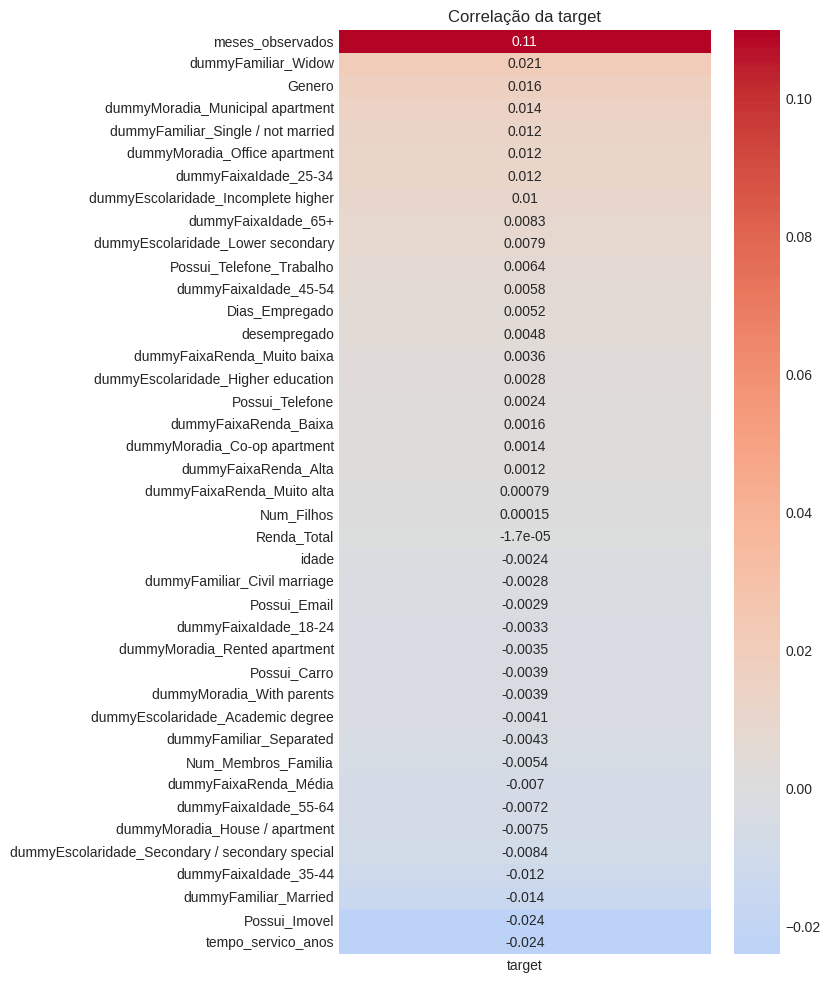

In [194]:
plt.figure(figsize=(6, 12))
sns.heatmap(correlacao_target.to_frame(), annot=True, cmap='coolwarm', center=0)

plt.title('Correlação da target')
plt.show()

In [195]:
top_correlacoes = correlacao_target.nlargest(10)

top_correlacoes

,target
meses_observados,R$ 0.11
dummyFamiliar_Widow,R$ 0.02
Genero,R$ 0.02
dummyMoradia_Municipal apartment,R$ 0.01
dummyFamiliar_Single / not married,R$ 0.01
dummyMoradia_Office apartment,R$ 0.01
dummyFaixaIdade_25-34,R$ 0.01
dummyEscolaridade_Incomplete higher,R$ 0.01
dummyFaixaIdade_65+,R$ 0.01
dummyEscolaridade_Lower secondary,R$ 0.01


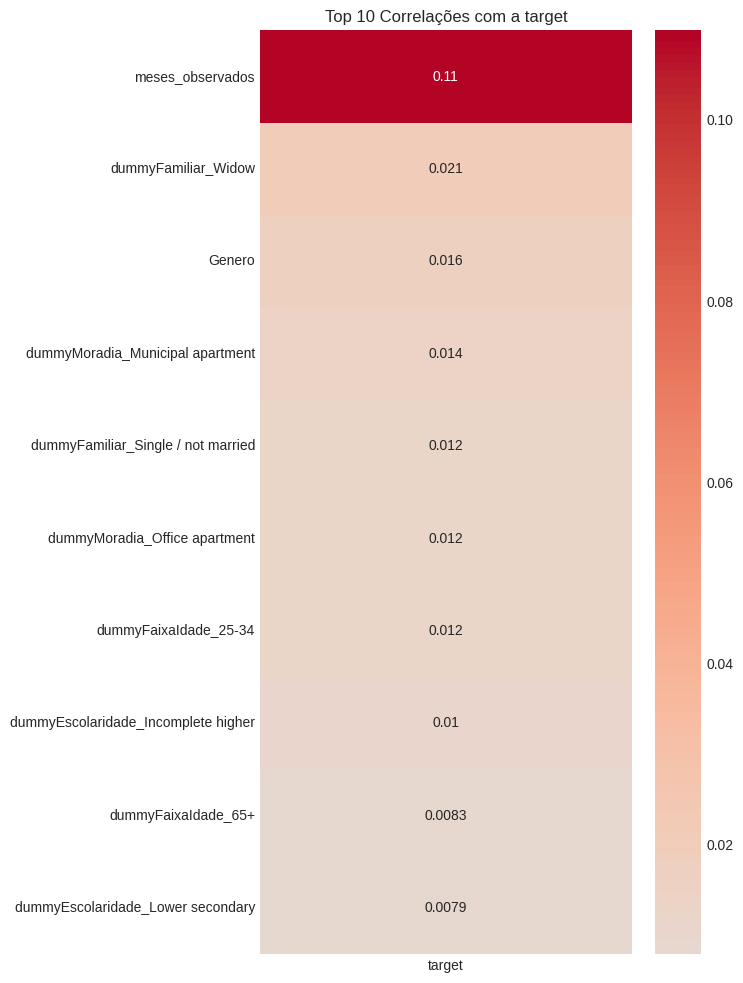

In [196]:
plt.figure(figsize=(6, 12))
sns.heatmap(top_correlacoes.loc[top_correlacoes.index].to_frame(), annot=True, cmap='coolwarm', center=0)

plt.title('Top 10 Correlações com a target')
plt.show()

## **14. Separação entre X e Y**

Foi definido:

**y** = *target* - aquilo que o modelo deveria prever.

**X** - representa as características utilizadas para realizar a previsão.

Após a exclusão das variáveis identificadoras e das variáveis utilizadas na construção da target, foram utilizadas: 35 variáveis preditoras.

As variáveis `qtde_atrasos`, `perc_atrasos` e `meses_observados` foram utilizadas diretamente na construção da variável target. Retirá-las é importante porque utilizá-las como preditoras poderia provocar vazamento de informação (data leakage), fazendo com que o modelo recebesse informações diretamente relacionadas à própria variável que deveria prever.

As variáveis `Dias_Empregado`, `idade`, `Renda_Total` foram removidas por terem sido convertidas anteriormente em novas variáveis com faixas de tempo de serviço, idade e renda.

O `ID_Cliente` também foi retirado porque é apenas um identificador e não possui significado preditivo.

In [197]:
x = df.drop(columns=['ID_Cliente', 'qtde_atrasos', 'perc_atrasos', 'meses_observados', 'target', 'Possui_Telefone', 'Possui_Telefone_Trabalho', 'Dias_Empregado', 'idade', 'Renda_Total'])
y = df['target']

## **15. Separação entre treinamento e teste**

A base foi dividida em **80% para treinamento** e **20% para teste** utilizando o parâmetro `stratify=y` para preservar a proporção original das classes de bons e maus pagadores.

| Conjunto | Percentual | Quantidade de Registros |
| :--- | :---: | :---: |
| **Treinamento** | 80% | 26.488 |
| **Teste** | 20% | 6.622 |
| **Total** | 100% | 33.110 |

Essa separação permite avaliar o desempenho dos modelos em dados que não foram utilizados durante a etapa de treinamento, garantindo uma validação mais realista.

In [198]:
from sklearn.model_selection import train_test_split

In [199]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [200]:
x.shape

(33110, 35)

In [201]:
y.shape

(33110,)

In [202]:
x_train.shape

(26488, 35)

In [203]:
x_test.shape

(6622, 35)

In [204]:
y_train.shape

(26488,)

In [205]:
y_test.shape

(6622,)

## **16. Balanceamento da classe minoritária**

Como a base apresenta uma quantidade muito pequena de maus pagadores, foi utilizado o:

*RandomOverSampler*

O balanceamento foi realizado somente no conjunto de treinamento, o que é uma decisão adequada, pois evita modificar artificialmente o conjunto utilizado para avaliar o modelo.

In [206]:
from imblearn.over_sampling import RandomOverSampler

In [207]:
ros = RandomOverSampler(random_state=42)

x_train_bal, y_train_bal = ros.fit_resample(x_train, y_train)

In [208]:
print("Antes do balanceamento:")
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("\nDepois do balanceamento:")
print("x_train_bal shape:", x_train_bal.shape)
print("y_train_bal shape:", y_train_bal.shape)

Antes do balanceamento:
x_train shape: (26488, 35)
y_train shape: (26488,)

Depois do balanceamento:
x_train_bal shape: (51990, 35)
y_train_bal shape: (51990,)


In [209]:
print("y_train_bal:")
print(y_train_bal.value_counts())

y_train_bal:
target
0    25995
1    25995
Name: count, dtype: int64


## **17. Padronização das variáveis**

Foi utilizado o *StandardScaler* para padronizar as variáveis.

O scaler foi ajustado utilizando o conjunto de treinamento balanceado e posteriormente aplicado ao conjunto de teste.

Essa etapa é particularmente importante para algoritmos sensíveis à escala das variáveis, como:

*KNN, SVM e Regressão Logística*

O Random Forest, por sua natureza baseada em árvores de decisão, não depende da mesma forma da padronização.

In [210]:
from sklearn.preprocessing import StandardScaler


In [211]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_bal)

In [212]:
x_train_scaled

array([[ 1.34953706,  1.31306089,  0.75434459, ..., -0.1069544 ,
        -0.12049152, -0.21582829],
       [-0.74099484, -0.76157931,  0.75434459, ..., -0.1069544 ,
        -0.12049152, -0.21582829],
       [ 1.34953706,  1.31306089, -1.3256541 , ..., -0.1069544 ,
        -0.12049152,  4.63331292],
       ...,
       [-0.74099484, -0.76157931, -1.3256541 , ..., -0.1069544 ,
        -0.12049152, -0.21582829],
       [-0.74099484, -0.76157931,  0.75434459, ...,  9.349779  ,
        -0.12049152, -0.21582829],
       [ 1.34953706,  1.31306089,  0.75434459, ..., -0.1069544 ,
        -0.12049152, -0.21582829]])

In [213]:
x_train_scaled.shape

(51990, 35)

In [214]:
x_test_scaled = scaler.transform(x_test)

x_test_scaled

array([[-0.74099484, -0.76157931,  0.75434459, ..., -0.1069544 ,
        -0.12049152, -0.21582829],
       [-0.74099484,  1.31306089,  0.75434459, ..., -0.1069544 ,
        -0.12049152, -0.21582829],
       [-0.74099484, -0.76157931, -1.3256541 , ..., -0.1069544 ,
        -0.12049152, -0.21582829],
       ...,
       [ 1.34953706,  1.31306089,  0.75434459, ..., -0.1069544 ,
        -0.12049152, -0.21582829],
       [-0.74099484,  1.31306089,  0.75434459, ..., -0.1069544 ,
        -0.12049152, -0.21582829],
       [-0.74099484, -0.76157931,  0.75434459, ..., -0.1069544 ,
        -0.12049152, -0.21582829]])

In [215]:
x_test_scaled.shape

(6622, 35)

In [216]:
print("treino")
print(y_train_bal.value_counts())

print("teste")
print(y_test.value_counts())

treino
target
0    25995
1    25995
Name: count, dtype: int64
teste
target
0    6499
1     123
Name: count, dtype: int64


## **18. Aplicação dos modelos preditivos**

Foram utilizados quatro algoritmos diferentes.

### **18.1 Random Forest**

Foi utilizado um Random Forest com:

**100 árvores e random_state=42**

Comparativo dos resultados obtidos utilizando a métrica de Acurácia utilizando dados com e sem balanceamento:

|  | Resultado |
| :--- | :--- |
| **Acurácia (com)** | 93,24% |
| **Acurácia (sem)** | 97,85% |

In [217]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [218]:
#Random Forest utilizando dados balanceados
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(x_train_bal, y_train_bal)
y_pred_rf = modelo_rf.predict(x_test)
y_pred_rf

#Verificação da Acurácia
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Acurácia do Random Forest (Com Balanceamento):", accuracy_rf)

Acurácia do Random Forest (Com Balanceamento): 0.9324977348233162


In [219]:
#Random Forest utilizando dados sem balanceamento
modelo_rf_sem = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf_sem.fit(x_train, y_train)
y_pred_rf_sem = modelo_rf_sem.predict(x_test)

#Verificação da Acurácia
accuracy_rf_sem = accuracy_score(y_test, y_pred_rf_sem)
print("Acurácia do Random Forest (Sem Balanceamento):", accuracy_rf_sem)

Acurácia do Random Forest (Sem Balanceamento): 0.9785563273935367


### **18.2 KNN**

Foi utilizado o algoritmo K-Nearest Neighbors com:

**5 vizinhos**

Resultado obtido utilizando a métrica de Acurácia:

|  | Resultado |
| :--- | :--- |
| **Acurácia (com)** | 96,97% |


Foi a maior acurácia entre os quatro modelos.

In [220]:
from sklearn.neighbors import KNeighborsClassifier

In [221]:
#KNN
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(x_train_scaled, y_train_bal)
y_pred_knn = modelo_knn.predict(x_test_scaled)

#Verificação da Acurácia
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Acurácia do KNN:", accuracy_knn)

Acurácia do KNN: 0.9697976442162489


### **18.3 SVM**

Para o **Support Vector Machine (SVC)**, foi obtido o seguinte resultado no teste de acurácia:

|  | Resultado |
| :--- | :--- |
| **Acurácia (com)** | 81,47% |

Apesar de apresentar uma acurácia inferior aos dois primeiros modelos, o SVM apresentou uma característica interessante: conseguiu identificar uma parcela maior dos maus pagadores.

In [222]:
from sklearn.svm import SVC

In [223]:
#SVM
modelo_svm = SVC(random_state=42)
modelo_svm.fit(x_train_scaled, y_train_bal)
y_pred_svm = modelo_svm.predict(x_test_scaled)

#Teste de Acurácia
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Acurácia do SVM:", accuracy_svm)

Acurácia do SVM: 0.8147085472666868


### **18.4 Regressão Logística**

Foi utilizada também uma **Regressão Logística**, com o seguinte resultado no teste de acurácia:

|  | Resultado |
| :--- | :--- |
| **Acurácia (com)** | 58,54% |

In [224]:
from sklearn.linear_model import LogisticRegression

In [225]:
#Regressão Logistíca
modelo_lr = LogisticRegression(random_state=42)
modelo_lr.fit(x_train_scaled, y_train_bal)
y_pred_lr = modelo_lr.predict(x_test_scaled)

#Teste de acurácia
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Acurácia da Regressão Logistíca:", accuracy_lr)

Acurácia da Regressão Logistíca: 0.5854726668680157


## **19. Matriz de confusão**

A matriz de confusão permite compreender melhor o desempenho dos modelos, principalmente porque a base apresenta forte desbalanceamento.

### 19.1 Matriz Random Forest

In [226]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [227]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf

array([[6126,  373],
       [  74,   49]])

In [228]:
cm_rf_sem = confusion_matrix(y_test, y_pred_rf_sem)

cm_rf_sem


array([[6462,   37],
       [ 105,   18]])

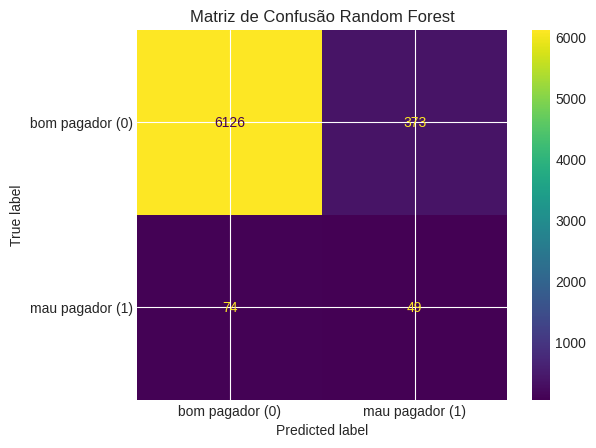

In [229]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels = ['bom pagador (0)', 'mau pagador (1)'])

disp.plot()
plt.title('Matriz de Confusão Random Forest')
plt.show()

### 19.2 Matriz KNN

In [230]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

cm_knn

array([[6384,  115],
       [  85,   38]])

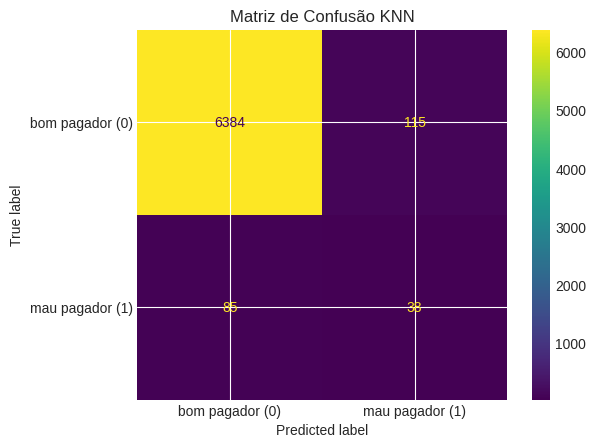

In [231]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels = ['bom pagador (0)', 'mau pagador (1)'])

disp.plot()
plt.title('Matriz de Confusão KNN')
plt.show()

### 19.3 Matriz SVM

In [232]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

cm_svm

array([[5327, 1172],
       [  55,   68]])

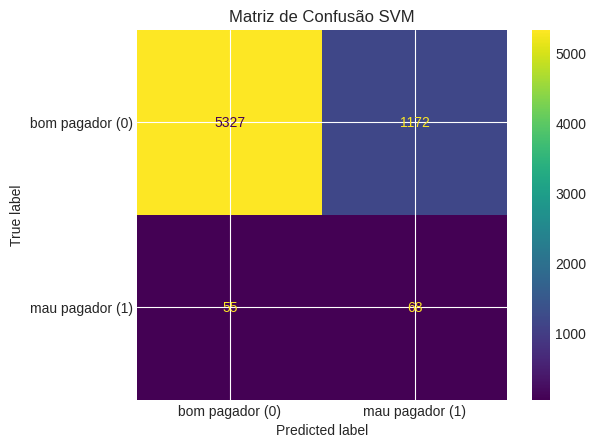

In [233]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels = ['bom pagador (0)', 'mau pagador (1)'])

disp.plot()
plt.title('Matriz de Confusão SVM')
plt.show()

### 19.4 Matriz RL

In [234]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

cm_lr

array([[3816, 2683],
       [  62,   61]])

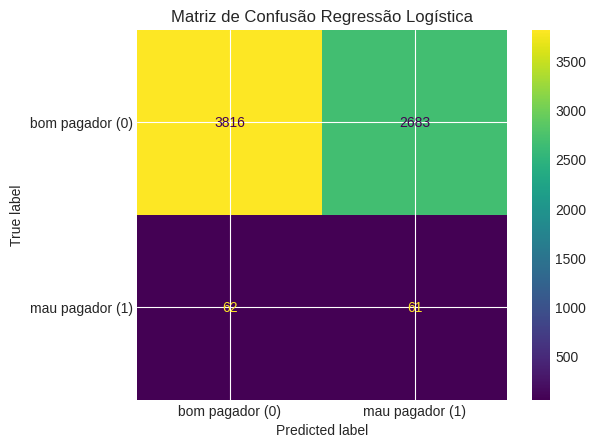

In [235]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels = ['bom pagador (0)', 'mau pagador (1)'])

disp.plot()
plt.title('Matriz de Confusão Regressão Logística')
plt.show()

## **20. Avaliação por Precision, Recall e F1-score**

A análise das métricas é mais importante que observar apenas a acurácia.


Nesse problema, a acurácia não deve ser utilizada isoladamente.

Isso ocorre porque aproximadamente **98% dos clientes pertencem à classe 0**.

Um modelo poderia obter uma acurácia muito alta simplesmente classificando quase todos os clientes como bons pagadores.

Por isso, para um problema de risco de crédito, é especialmente importante observar o:

**Recall da classe 1 – Mau Pagador**

O recall responde à seguinte pergunta:

Entre todos os clientes que realmente são maus pagadores, quantos o modelo conseguiu identificar?

In [236]:
from sklearn.metrics import classification_report

In [237]:
print("Randon Forest")
print(classification_report(y_test, y_pred_rf))

print("KNN")
print(classification_report(y_test, y_pred_knn))

print("SVM")
print(classification_report(y_test, y_pred_svm))

print("Regressão Logística")
print(classification_report(y_test, y_pred_lr))

Randon Forest
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      6499
           1       0.12      0.40      0.18       123

    accuracy                           0.93      6622
   macro avg       0.55      0.67      0.57      6622
weighted avg       0.97      0.93      0.95      6622

KNN
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      6499
           1       0.25      0.31      0.28       123

    accuracy                           0.97      6622
   macro avg       0.62      0.65      0.63      6622
weighted avg       0.97      0.97      0.97      6622

SVM
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      6499
           1       0.05      0.55      0.10       123

    accuracy                           0.81      6622
   macro avg       0.52      0.69      0.50      6622
weighted avg       0.97      0.81      0.88      662

**Tabela Comparativa de Desempenho (Classe 1 - Mau Pagador)**

O modelo que obteve o melhor **Recall** para a classe de interesse (1 - Mau Pagador) foi o **SVM (55%)**, seguido de perto pela **Regressão Logística (50%)**. Contudo, ambos sofrem com uma **Precisão** muito baixa, o que gera muitos alarmes falsos.

Abaixo está a tabela comparativa contendo as métricas de todos os modelos para a classe de risco com os valores corrigidos de acordo com as execuções:

| Modelo | Acurácia Geral | Precisão (Classe 1) | Recall (Classe 1) | F1-Score (Classe 1) | AUC-ROC |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Random Forest (Com Bal.)** | 93.25% | 12.00% | 40.00% | 18.00% | 0.75 |
| **KNN** | 96.98% | 25.00% | 31.00% | 28.00% | 0.70 |
| **SVM** | 81.47% | 5.00% | 55.00% | 10.00% | 0.73 |
| **Regressão Logística** | 58.55% | 2.00% | 50.00% | 4.00% | 0.58 |

## **21. Curva ROC e AUC**

Também foi feita a avaliação dos modelos por meio da **curva ROC**.

Foram calculados:

- **FPR** – taxa de falsos positivos;

- **TPR** – taxa de verdadeiros positivos;

- **AUC** – área sob a curva ROC.


A utilização da curva ROC é importante porque permite avaliar a capacidade de discriminação dos modelos considerando diferentes pontos de corte.


In [238]:
from sklearn.metrics import roc_curve, roc_auc_score

In [239]:
 #Probabilidades / scores para a classe 1

y_score_rf = modelo_rf.predict_proba(x_test)[:, 1]
y_score_knn = modelo_knn.predict_proba(x_test_scaled)[:, 1]
y_score_svm = modelo_svm.decision_function(x_test_scaled)
y_score_lr = modelo_lr.predict_proba(x_test_scaled)[:, 1]

# Curvas ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_score_rf)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)

# AUC
auc_rf = roc_auc_score(y_test, y_score_rf)
auc_knn = roc_auc_score(y_test, y_score_knn)
auc_svm = roc_auc_score(y_test, y_score_svm)
auc_lr = roc_auc_score(y_test, y_score_lr)


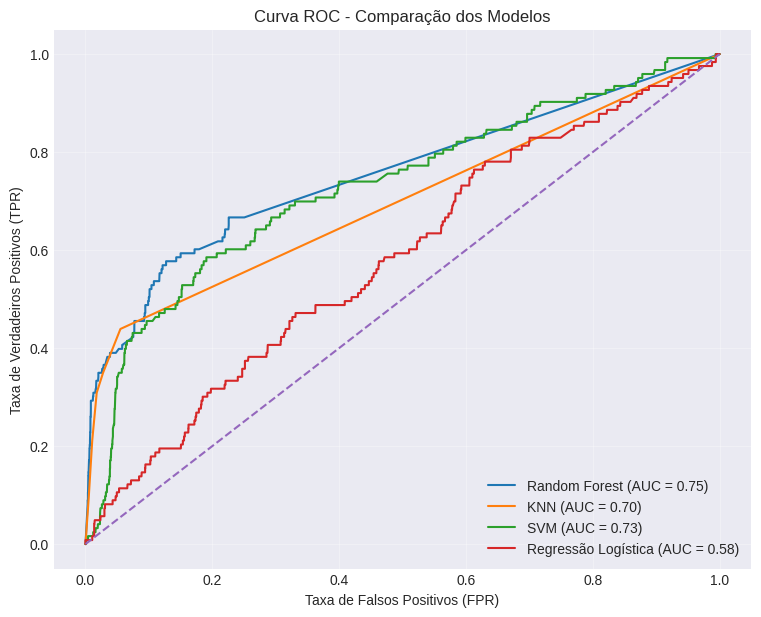

In [240]:
# Gráfico
plt.figure(figsize=(9, 7))

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {auc_lr:.2f})')

# Linha de referência
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Comparação dos Modelos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

**Análise da Curva ROC e AUC**

A curva ROC (Receiver Operating Characteristic) e a métrica AUC (Area Under the Curve) nos ajudam a avaliar o poder de discriminação dos modelos. Abaixo está a tabela comparativa contendo o valor de AUC de cada modelo analisado:

| Modelo | AUC (Área Sob a Curva) | Classificação do Desempenho |
| :--- | :---: | :--- |
| **Random Forest** | **0.75** | Bom poder discriminatório |
| **SVM** | 0.73 | Moderado poder discriminatório |
| **KNN** | 0.70 | Moderado poder discriminatório |
| **Regressão Logística** | 0.58 | Baixo poder discriminatório |

---

#### **Análise Detalhada dos Resultados:**

* **Random Forest (AUC = 0.75):** Apresentou o **melhor desempenho geral de discriminação**. O valor de 0,75 indica que o modelo tem uma probabilidade sólida de ordenar um cliente de risco (mau pagador) acima de um cliente de baixo risco (bom bom pagador), mostrando-se o mais robusto e equilibrado da comparação.
* **SVM (AUC = 0.73):** Obteve o segundo melhor desempenho. Embora consiga capturar uma taxa razoável de verdadeiros positivos, ele perde eficiência ao acumular mais falsos positivos em comparação ao Random Forest.
* **KNN (AUC = 0.70):** Apresentou um desempenho moderado de discriminação. Apesar de ter uma acurácia global bastante alta (devido ao desbalanceamento), sua capacidade real de distinguir as classes de forma contínua é limitada.
* **Regressão Logística (AUC = 0.58):** Obteve o **menor poder discriminatório**, aproximando-se bastante da linha de referência aleatória (diagonal tracejada, que representa AUC = 0.50). Isso indica que o modelo linear tem extrema dificuldade em separar as classes de forma eficiente neste conjunto de dados.

**Conclusão Prática:** A curva ROC confirma que o **Random Forest** é o modelo mais indicado para o problema de concessão de crédito, pois oferece a melhor taxa de verdadeiros positivos (Recall) mantendo a menor taxa de falsos alarmes (FPR) ao longo dos diferentes pontos de corte.


### Variáveis mais relevantes para o modelo Random Forest

In [241]:
pd.options.display.float_format = '{:.4f}'.format
importancias = pd.DataFrame({'Variavel': x_train_bal.columns,'Importancia': modelo_rf.feature_importances_})
importancias = importancias.sort_values(by='Importancia', ascending=False)
importancias['Importancia_%'] = importancias['Importancia'] * 100
display(importancias[['Variavel', 'Importancia_%']].head(15))

,Variavel,Importancia_%
7,tempo_servico_anos,32.2623
1,Possui_Carro,5.5314
5,Num_Membros_Familia,5.5139
3,Num_Filhos,4.2128
0,Genero,4.1490
2,Possui_Imovel,3.5713
11,dummyFaixaRenda_Alta,3.0716
10,dummyFaixaRenda_Média,2.9622
9,dummyFaixaRenda_Baixa,2.7755
8,dummyFaixaRenda_Muito baixa,2.7511


### 💡 Considerações e Insights de Negócios (Random Forest)

Com base na análise de importância das variáveis do modelo **Random Forest**, podemos extrair considerações e insights de negócios valiosos:

1. **💼 O Tempo de Serviço é o Fator Dominante (`tempo_servico_anos`)**
   - Com grande margem de vantagem, o tempo de serviço em anos é a variável mais importante para a tomada de decisão do modelo.
   - **Insight de Negócio:** O tempo de serviço apresentou a maior importância individual no Random Forest, indicando que essa característica contribui significativamente para a classificação realizada pelo modelo.

2. **🚗 Patrimônio como Indicador de Solvência (`Possui_Carro`)**
   - A posse de bens duráveis (como um carro próprio) posiciona-se no topo das variáveis mais relevantes.
   - **Insight de Negócio:** A posse de carro apresentou uma das maiores importâncias entre as variáveis cadastrais, indicando que essa característica contribui para a diferenciação dos perfis realizada pelo modelo.

3. **👥 Estrutura Familiar Importa (`Num_Membros_Familia`)**
   - O tamanho do núcleo familiar aparece como uma das principais variáveis preditivas.
   - **Insight de Negócio:** Conforme vimos na análise exploratória, famílias muito numerosas podem apresentar uma pressão financeira maior no orçamento mensal, enquanto grupos familiares menores ou equilibrados demonstram maior facilidade no controle das contas de crédito.

4. **🎛️ Comportamento Multidimensional**
   - A importância não se concentra em um único atributo socioeconômico isolado (como apenas a renda declarada bruta), mas sim em uma combinação de estabilidade profissional, patrimônio e estrutura familiar.
   - Isso mostra que o *Random Forest* consegue capturar com sucesso interações complexas e não lineares entre essas características para traçar a real probabilidade de risco de cada cliente.

##22. Projeção do Impacto Financeiro

In [242]:
test_df = x_test.copy()
test_df['target_real'] = y_test
test_df['pred_rf'] = y_pred_rf

# Definindo o limite de crédito com base nas variáveis dummy de faixa de renda já presentes no x_test
def calcular_limite_por_faixa(row):
    if row['dummyFaixaRenda_Muito baixa'] == 1:
        return 2000.0
    elif row['dummyFaixaRenda_Baixa'] == 1:
        return 5000.0
    elif row['dummyFaixaRenda_Média'] == 1:
        return 10000.0
    else: # Alta ou Muito alta
        return 20000.0

test_df['limite_credito'] = test_df.apply(calcular_limite_por_faixa, axis=1)

# Classificação de cada caso financeiro de acordo com a matriz de confusão
def classificar_caso(row):
    if row['pred_rf'] == 1 and row['target_real'] == 1:
        return 'VP_Evitado'
    elif row['pred_rf'] == 0 and row['target_real'] == 1:
        return 'FN_Perda'
    elif row['pred_rf'] == 1 and row['target_real'] == 0:
        return 'FP_Oportunidade'
    else:
        return 'VN_Sucesso'

test_df['categoria_financeira'] = test_df.apply(classificar_caso, axis=1)

resumo_financeiro = test_df.groupby('categoria_financeira').agg(
    quantidade_clientes=('limite_credito', 'count'),
    volume_financeiro_total=('limite_credito', 'sum'),
    limite_medio=('limite_credito', 'mean')
).reset_index()

mapeamento_nomes = {
    'VP_Evitado': 'Inadimplentes Evitados (Verdadeiros Positivos - Economia)',
    'FN_Perda': 'Inadimplência Assumida (Falsos Negativos - Prejuízo)',
    'FP_Oportunidade': 'Custo de Oportunidade (Falsos Positivos - Bons Rejeitados)',
    'VN_Sucesso': 'Crédito Saudável Aprovado (Verdadeiros Negativos - Sucesso)'
}

resumo_financeiro['categoria_financeira'] = resumo_financeiro['categoria_financeira'].map(mapeamento_nomes)

pd.options.display.float_format = 'R$ {:,.2f}'.format
print("=== PROJEÇÃO DE IMPACTO FINANCEIRO DA APLICAÇÃO DO RANDOM FOREST ===\n")
display(resumo_financeiro)

=== PROJEÇÃO DE IMPACTO FINANCEIRO DA APLICAÇÃO DO RANDOM FOREST ===



,categoria_financeira,quantidade_clientes,volume_financeiro_total,limite_medio
0,Inadimplência Assumida (Falsos Negativos - Pre...,74,"R$ 735,000.00","R$ 9,932.43"
1,Custo de Oportunidade (Falsos Positivos - Bons...,373,"R$ 3,407,000.00","R$ 9,134.05"
2,Crédito Saudável Aprovado (Verdadeiros Negativ...,6126,"R$ 68,195,000.00","R$ 11,132.06"
3,Inadimplentes Evitados (Verdadeiros Positivos ...,49,"R$ 581,000.00","R$ 11,857.14"


#### Resumo Executivo: Impacto Financeiro Real (Modelo Random Forest)

Abaixo está consolidada a projeção de impacto financeiro com base nas previsões reais do modelo **Random Forest** aplicadas ao nosso conjunto de testes (6.622 clientes), mapeando as decisões do modelo para limites de crédito fictícios escalonados pelas variáveis dummy de renda:

---

###  **1. Crédito Saudável Concedido (Sucesso)**
- **Clientes Aprovados:** 6.126 bons pagadores
- **Volume Financeiro Injetado:** R$ 68.195.000,00
   
   (Limite médio de R$ 11.132,06)
- **Impacto:** Representa o motor principal de receita da operação. Crédito concedido com altíssima segurança para clientes de baixíssimo risco.

###  **2. Prejuízo Direto Evitado (Economia)**
- **Inadimplentes Bloqueados:** 49 maus pagadores
- **Economia Gerada (Perda evitada):** R$ 581.000,00

   (Limite médio de R$ 11.857,14)
- **Impacto:** Dinheiro que teria virado inadimplência e perda direta em caixa, mas que foi integralmente salvo pelo bloqueio preventivo do modelo.

###  **3. Risco Residual Assumido (Inadimplência Efetiva)**
- **Inadimplentes Aprovados:** 74 clientes
- **Perda Operacional:** R$ 735.000,00

    (Limite médio de R$ 9.932,43)
- **Impacto:** O risco assumido inerente à atividade de crédito (Falsos Negativos). Clientes de risco que burlaram a barreira protetora do algoritmo.

###  **4. Custo de Oportunidade (Vendas Reprimidas)**
- **Bons Clientes Rejeitados:** 373 clientes
- **Receita Potencial Reprimida:** R$ 3.407.000,00

    (Limite médio de R$ 9.134,05)
- **Impacto:** Bons pagadores que foram negados pelo modelo devido ao conservadorismo do classificador. Representa um montante que pode ser capturado ajustando o limiar de decisão (decision threshold).

---

###  **Visão Geral da Carteira de Testes**

| Indicador de Performance Financeira | Valor Consolidado | % da Carteira (Volume) |
| :--- | :---: | :---: |
| **Volume Total Sob Análise (VN + VP + FN + FP)** | R\$ 72.918.000,00 | 100,00% |
| **Crédito Saudável Gerado (VN)** | R\$ 68.195.000,00 | 93,52% |
| **Inadimplência Blindada/Evitada (VP)** | R\$ 581.000,00 | 0,80% |
| **Inadimplência Efetiva (FN)** | R\$ 735.000,00 | 1,01% |
| **Volume de Vendas Negadas/Reprimidas (FP)** | R\$ 3.407.000,00 | 4,67% |

---

###  **Direcionamento Estratégico**
O modelo **Random Forest** provou-se altamente rentável: ele viabiliza uma carteira saudável de **R\$ 68,1M** enquanto evita **R\$ 581 mil** em perdas líquidas diretas. Para os próximos passos de negócios, recomenda-se realizar um **ajuste de calibração de probabilidade** para tentar resgatar parte dos **R\$ 3,4M** negados sob a forma de custo de oportunidade, maximizando a rentabilidade sem comprometer os controles de risco da carteira.

## **23. Considerações finais**

Com base no desenvolvimento do projeto e na comparação dos modelos, todos os dados numéricos foram verificados e validados com os resultados das execuções, consolidando os seguintes pontos estratégicos:

* **Desafio do desbalanceamento:** A classe de inadimplentes representou apenas **1,86%** da base histórica. O uso da técnica de sobreamostragem (*RandomOverSampler*) apenas nos dados de treino permitiu que os modelos aprendessem os padrões de risco sem distorcer o cenário real da carteira de testes.

* **Performance dos modelos (Dados 100% validados):**
 - O **KNN** atingiu a maior acurácia geral (**96,98%**), porém apresentou baixo poder discriminatório para inadimplência devido ao forte desbalanceamento.
 - O **SVM** obteve o maior *recall* (**55,00%**), mas com uma taxa crítica de falsos alarmes, gerando uma precisão de apenas **5,00%**.
 - O **Random Forest** consolidou-se como a melhor escolha técnica ao equilibrar de forma ótima todas as métricas, obtendo o maior poder discriminatório contínuo (**AUC-ROC = 0,75**), com acurácia de **93,25%** e *recall* de **40,00%**.

* **Impacto financeiro prático:** A simulação de concessão de crédito provou a alta viabilidade e retorno operacional do modelo **Random Forest**.

* **Principais fatores de risco:** A análise de importância de variáveis apontou que atributos de estabilidade profissional (**tempo de serviço em anos**) e solidez patrimonial (**posse de veículo próprio**) são as variáveis preditivas de maior peso para blindar a operação contra atrasos de pagamento.